In [18]:
## Data analysis phase

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import folium
from folium import  Marker
from folium.plugins import  MarkerCluster
import math


## Display all the columns of the dataframe
pd.set_option("display.max_columns", None)

In [19]:
from google.colab import files
uploaded = files.upload()

Saving Scraped_Data.csv to Scraped_Data.csv


In [20]:
import pandas as pd

df = pd.read_csv("Scraped_Data.csv")

In [21]:
df.head(10)

,exactPrice,sqftPrice,securityDeposit,propertyType,postedOn,noOfLifts,maintenanceChargesFrequency,maintenanceCharges,locality,furnishing,flrNum,firstMonthCharges,facing,totalFlrNum,city,carpetAreaUnit,carpetArea,brokerage,bedrooms,bathrooms,balconies,Water_Storage,Waste_Disposal,Visitor_Parking,Vaastu_Compliant,URLs,Swimming_Pool,Skydeck,Service_Or_Goods_Lift,Security,Retail_Boulevard___Retail_Shops__,Reserved_Parking,Rentable_Community_Space,RentOrSale,Recreational_Pool,Rain_Water_Harvesting,RO_Water_System,Private_Terrace_Or_Garden,Private_Garden,Power_Back_Up,Piped_Gas,Park,Outdoor_Tennis_Courts,Multipurpose_Hall,Multipurpose_Courts,Mini_Cinema_Theatre,Meditation_Area,Maintenance_Staff,Long,Lift,Library_And_Business_Centre,Library,Laundry_Service,Lat,Kids_Play_Pool_With_Water_Slides,Kids_Play_Area,Kids_Club,Jogging_and_Strolling_Track,Internet_Or_Wi_Fi_Connectivity,Intercom_Facility,Indoor_Squash__And__Badminton_Courts,Indoor_Games_Room,Health_club_with_Steam__Or__Jaccuzi,Gymnasium,Guest_Accommodation,Grand_Entrance_lobby,Golf_Course,Flower_Gardens,Fire_Fighting_Equipment,Event_Space__And__Amphitheatre,Earth_quake_resistant,Early_Learning_Centre,Dance_Studio,DTH_Television_Facility,Cycling__And__Jogging_Track,Cricket_net_practice,Conference_Room,Concierge_Services,Coffee_Lounge__And__Restaurants,Club_House,Canopy_Walk,Cafeteria_Or_Food_Court,CCTV_Camera,Barbeque_Pit,Bar_Or_Lounge,Banquet_Hall,Bank__And__ATM,Arts__And__Craft_Studio,Air_Conditioned,Activity_Deck4,AEROBICS_ROOM
0,240000,171,9,Multistorey Apartment,"Jun 20, '23",9.0,9,9,Danapur,Semi-Furnished,4,9,9,6,Patna,9,9,9,3,2,9,1,0,1,1,https://www.magicbricks.com/propertyDetails/3-...,1,0,0,1,0,1,0,Rent,0,1,0,0,0,1,1,1,1,0,0,0,0,1,85.056330,0,0,0,0,25.605898,0,0,0,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,1,1,0,0,0,0,0
1,12000,12,12000,Multistorey Apartment,"Jun 19, '23",1.0,Monthly,1500,9,Semi-Furnished,4,25500,9,5,Patna,Sq-ft,900,9,2,2,2,9,9,9,9,https://www.magicbricks.com/propertyDetails/2-...,9,9,9,9,9,9,9,Rent,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9.000000,9,9,9,9,9.000000,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9
2,17000,7,9,Residential House,"Jun 21, '23",9.0,9,9,Phase 1 Ashiana Nagar,Semi-Furnished,Ground,9,9,2,Patna,Sq-ft,1300,9,3,3,3,9,9,9,9,https://www.magicbricks.com/propertyDetails/3-...,9,9,9,9,9,9,9,Rent,9,9,9,9,9,9,9,9,9,9,9,9,9,9,85.079964,9,9,9,9,25.621426,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9
3,5000,9,9,Residential House,"Jun 23, '23",9.0,9,9,Kumhrar,Furnished,9,9,9,3,Patna,Sq-ft,120,9,1,1,9,9,9,9,9,https://www.magicbricks.com/propertyDetails/1-...,9,9,9,9,9,9,9,Rent,9,9,9,9,9,9,9,9,9,9,9,9,9,9,85.185006,9,9,9,9,25.593090,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9
4,12000,9,24000,Multistorey Apartment,"Jun 24, '23",1.0,Monthly,500,Kumhrar,Unfurnished,1,36500,East,5,Patna,Sq-ft,1200,9,2,2,3,9,9,9,9,https://www.magicbricks.com/propertyDetails/2-...,9,9,9,9,9,9,9,Rent,9,9,9,9,9,9,9,9,9,9,9,9,9,9,85.185005,9,9,9,9,25.593090,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9
5,18000,16,9,Multistorey Apartment,"Jun 24, '23",9.0,9,9,Lalji Tola,Unfurnished,1,9,North,4,Patna,Sq-ft,1040,9,2,2,2,9,9,9,9,https://www.magicbricks.com/propertyDetails/2-...,9,9,9,9,9,9,9,Rent,9,9,9,9,9,9,9,9,9,9,9,9,9,9,85.144040,9,9,9,9,25.605076,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9
6,8500,7,9,Multistorey Apartment,"Jun 24, '23",9.0,Monthly,500,Mitra Mandal Colony,Semi-Furnished,2,9000,East,3,Patna,Sq-ft,1000,9,2,1,9,9,9,9,9,https://www.magicbricks.com/propertyDetails/2-...,9,9,9,9,9,9,9,Rent,9,9,9,9,9,9,9,9,9,9,9,9,9,9,85.085995,9,9,9,9,25.581001,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9
7,10000,8,20000,Multistorey Apartment,"Jun 24, '23",9.0,Monthly,2000,9,Unfurnished,Ground,32000,9,5,Patna,Sq-ft,930,9,2,2,3,9,9,9,9,https://www.magicbricks.com/propertyDetails/2-...,9,9,9,9,9,9,9,Rent,9,9,9,9,

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27900 entries, 0 to 27899
Data columns (total 91 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   exactPrice                            27900 non-null  int64  
 1   sqftPrice                             27900 non-null  int64  
 2   securityDeposit                       27900 non-null  int64  
 3   propertyType                          27900 non-null  object 
 4   postedOn                              27900 non-null  object 
 5   noOfLifts                             27445 non-null  float64
 6   maintenanceChargesFrequency           27900 non-null  object 
 7   maintenanceCharges                    27900 non-null  int64  
 8   locality                              27900 non-null  object 
 9   furnishing                            27900 non-null  object 
 10  flrNum                                27900 non-null  object 
 11  firstMonthCharg

In [ ]:
df.shape

(27900, 91)

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
noOfLifts,455
city,1
sqftPrice,0
securityDeposit,0
propertyType,0
...,...
Bank__And__ATM,0
Arts__And__Craft_Studio,0
Air_Conditioned,0
Activity_Deck4,0


In [ ]:
pd.set_option('display.max_rows', None)

df.isnull().sum().sort_values(ascending=False)

,0
noOfLifts,455
city,1
sqftPrice,0
securityDeposit,0
propertyType,0
postedOn,0
maintenanceChargesFrequency,0
maintenanceCharges,0
locality,0
furnishing,0


In [ ]:
df.duplicated().sum()

np.int64(11)

In [73]:
df['city'].fillna(df['city'].mode()[0], inplace=True)

/tmp/ipykernel_3949/3130792203.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['city'].fillna(df['city'].mode()[0], inplace=True)


In [ ]:
df['noOfLifts'].value_counts(dropna=False)

,count
noOfLifts,
9.0,22974
2.0,2384
1.0,1296
NaN,455
3.0,357
4.0,256
5.0,72
6.0,63
8.0,19


In [74]:
df = df.drop_duplicates()

In [75]:
df['city'] = df['city'].fillna(df['city'].mode()[0])

In [76]:
df['noOfLifts'] = df['noOfLifts'].fillna(df['noOfLifts'].median())

In [77]:
df['RentOrSale'].value_counts()

,count
RentOrSale,
Rent,16026
Sale,11843
9,20


In [78]:
df['exactPrice'].describe()

,exactPrice
count,2.788900e+04
mean,5.429673e+06
std,2.700097e+07
min,9.000000e+00
25%,1.300000e+04
50%,3.000000e+04
75%,5.288000e+06
max,3.250000e+09


In [79]:
df[['exactPrice']].head()

,exactPrice
0,240000
1,12000
2,17000
3,5000
4,12000


In [ ]:
# Count unique values in RentOrSale column
print(df['RentOrSale'].value_counts())

# Check if there are any unusual values
print(df['RentOrSale'].unique())

RentOrSale
Rent    16026
Sale    11843
9          20
Name: count, dtype: int64
['Rent' '9' 'Sale']


In [ ]:
# Remove invalid transaction type records
df = df[df['RentOrSale'].isin(['Rent', 'Sale'])]

# Verify the result
print(df['RentOrSale'].value_counts())

RentOrSale
Rent    16026
Sale    11843
Name: count, dtype: int64


In [80]:
# Create dataset for sale properties only
df_sale = df[df['RentOrSale'] == 'Sale'].copy()

print(df_sale.shape)

(11843, 91)


In [28]:
# Basic statistics of target variable
print(df_sale['exactPrice'].describe())

# Check skewness of sale prices
print("Skewness:", df_sale['exactPrice'].skew())

count    1.184300e+04
mean     1.273965e+07
std      4.028651e+07
min      9.000000e+00
25%      3.500000e+06
50%      6.480000e+06
75%      1.146200e+07
max      3.250000e+09
Name: exactPrice, dtype: float64
Skewness: 47.59280096949559


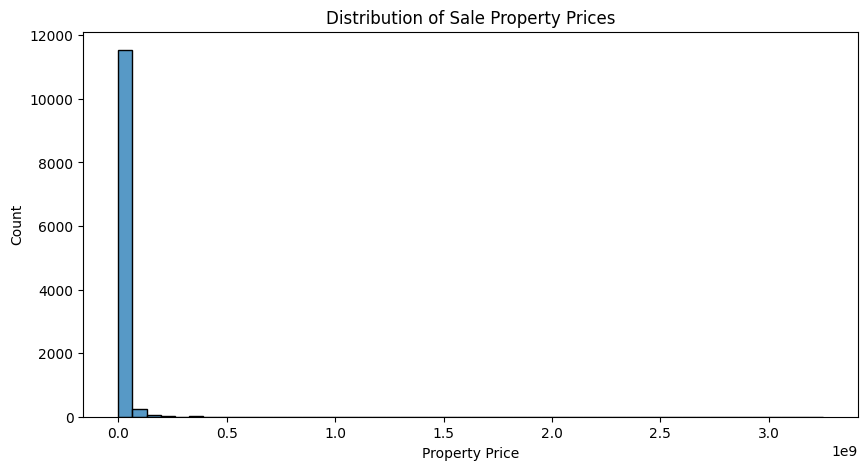

In [29]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of property prices
plt.figure(figsize=(10,5))
sns.histplot(df_sale['exactPrice'], bins=50)
plt.title("Distribution of Sale Property Prices")
plt.xlabel("Property Price")
plt.ylabel("Count")
plt.show()

In [ ]:
# Check the cheapest properties
df_sale[['exactPrice', 'city', 'propertyType', 'bedrooms']].sort_values(
    by='exactPrice'
).head(10)

,exactPrice,city,propertyType,bedrooms
15254,9,Raipur,Multistorey Apartment,3
15266,9,Raipur,Residential House,2
15263,9,Raipur,Residential House,3
15261,9,Raipur,Residential House,2
15260,9,Raipur,Residential House,1
15259,9,Raipur,Multistorey Apartment,2
15258,9,Raipur,Residential House,1
15257,9,Raipur,Multistorey Apartment,3
15256,9,Raipur,Multistorey Apartment,1
15255,9,Raipur,Multistorey Apartment,2


In [ ]:
# Check the most expensive properties
df_sale[['exactPrice', 'city', 'propertyType', 'bedrooms']].sort_values(
    by='exactPrice',
    ascending=False
).head(10)

,exactPrice,city,propertyType,bedrooms
20932,3250000000,Chandigarh,Residential House,6
20062,850000000,Chandigarh,Villa,6
20110,780000000,Chandigarh,Villa,6
24771,750000000,Mumbai,Multistorey Apartment,5
20613,570000000,Chandigarh,Villa,6
22382,525000000,Mumbai,Multistorey Apartment,6
21866,500000000,Mumbai,Multistorey Apartment,6
20768,480000000,Chandigarh,Villa,6
20299,460000000,Chandigarh,Villa,6
20160,450000000,Chandigarh,Villa,6


In [ ]:
# Number of unique cities
print(df_sale['city'].nunique())

# Top 20 cities by property count
print(df_sale['city'].value_counts().head(20))

10
city
Chandigarh    1478
Patna         1402
Bhopal        1397
Dehradun      1383
Goa           1373
Jaipur        1284
Lucknow       1201
Raipur        1186
Mumbai        1137
Gangtok          2
Name: count, dtype: int64


In [ ]:
# Remove properties with invalid sale prices

df_sale = df_sale[df_sale['exactPrice'] > 1000]

# Verify minimum price
print(df_sale['exactPrice'].min())

# Check new shape
print(df_sale.shape)

100000
(10823, 91)


In [ ]:
print(df_sale.columns.tolist())

['exactPrice', 'sqftPrice', 'securityDeposit', 'propertyType', 'postedOn', 'noOfLifts', 'maintenanceChargesFrequency', 'maintenanceCharges', 'locality', 'furnishing', 'flrNum', 'firstMonthCharges', 'facing', 'totalFlrNum', 'city', 'carpetAreaUnit', 'carpetArea', 'brokerage', 'bedrooms', 'bathrooms', 'balconies', 'Water_Storage', 'Waste_Disposal', 'Visitor_Parking', 'Vaastu_Compliant', 'URLs', 'Swimming_Pool', 'Skydeck', 'Service_Or_Goods_Lift', 'Security', 'Retail_Boulevard___Retail_Shops__', 'Reserved_Parking', 'Rentable_Community_Space', 'RentOrSale', 'Recreational_Pool', 'Rain_Water_Harvesting', 'RO_Water_System', 'Private_Terrace_Or_Garden', 'Private_Garden', 'Power_Back_Up', 'Piped_Gas', 'Park', 'Outdoor_Tennis_Courts', 'Multipurpose_Hall', 'Multipurpose_Courts', 'Mini_Cinema_Theatre', 'Meditation_Area', 'Maintenance_Staff', 'Long', 'Lift', 'Library_And_Business_Centre', 'Library', 'Laundry_Service', 'Lat', 'Kids_Play_Pool_With_Water_Slides', 'Kids_Play_Area', 'Kids_Club', 'Joggin

In [ ]:
# Check whether sqftPrice is derived from exactPrice

df_sale[['exactPrice', 'sqftPrice', 'carpetArea']].head(10)

,exactPrice,sqftPrice,carpetArea
11936,7208000,4870,1043
11937,5040000,4800,9
11938,6187500,4500,1250
11939,5731000,5505,9
11940,8593200,6200,9
11941,9500000,6230,1521
11942,7750000,5000,1162
11943,6050000,5000,9
11944,8370000,5400,9
11945,9025500,5500,9


In [81]:
# Columns that should not be used for prediction
drop_cols = [
    'URLs',          # unique identifier/link
    'RentOrSale'     # all rows are Sale now
]

In [82]:
# Check if amenity columns are binary (0/1)

amenity_cols = [
    'Swimming_Pool',
    'Gymnasium',
    'Club_House',
    'Security',
    'CCTV_Camera'
]

for col in amenity_cols:
    print(f"\n{col}")
    print(df_sale[col].value_counts().head())


Swimming_Pool
Swimming_Pool
9    8770
1    2027
0    1046
Name: count, dtype: int64

Gymnasium
Gymnasium
9    8770
1    2219
0     854
Name: count, dtype: int64

Club_House
Club_House
9    8770
1    1803
0    1270
Name: count, dtype: int64

Security
Security
9    8770
1    2496
0     577
Name: count, dtype: int64

CCTV_Camera
CCTV_Camera
9    8770
0    2419
1     654
Name: count, dtype: int64


In [83]:
# Check how many 9s exist in important columns

cols = [
    'carpetArea',
    'sqftPrice',
    'bedrooms',
    'bathrooms',
    'balconies',
    'Swimming_Pool',
    'Gymnasium',
    'Security'
]

for col in cols:
    print(f"{col}:")
    print(df_sale[col].value_counts().head())
    print("-"*40)

carpetArea:
carpetArea
9       5480
1000     253
1200     187
1100     184
900      170
Name: count, dtype: int64
----------------------------------------
sqftPrice:
sqftPrice
9       1586
5000     172
4000     118
3000     112
3333      96
Name: count, dtype: int64
----------------------------------------
bedrooms:
bedrooms
3    4528
2    4054
4    1297
1     877
5     410
Name: count, dtype: int64
----------------------------------------
bathrooms:
bathrooms
2    5536
3    3086
4    1066
1    1022
5     434
Name: count, dtype: int64
----------------------------------------
balconies:
balconies
9    4727
2    2725
1    2215
3    1475
4     540
Name: count, dtype: int64
----------------------------------------
Swimming_Pool:
Swimming_Pool
9    8770
1    2027
0    1046
Name: count, dtype: int64
----------------------------------------
Gymnasium:
Gymnasium
9    8770
1    2219
0     854
Name: count, dtype: int64
----------------------------------------
Security:
Security
9    8770
1    24

In [84]:
# Exclude carpetArea = 9 rows temporarily
temp = df_sale[df_sale['carpetArea'] != 9]

# Check relationship
temp[['exactPrice', 'carpetArea', 'sqftPrice']].head(10)

,exactPrice,carpetArea,sqftPrice
11936,7208000,1043,4870
11938,6187500,1250,4500
11941,9500000,1521,6230
11942,7750000,1162,5000
11949,9300000,1580,5849
11950,11291000,966,7000
11951,5200800,650,5094
11958,6900000,1300,5111
11959,12636200,1258,8200
11961,6395400,876,5100


In [85]:
# Remove target leakage feature
df_sale = df_sale.drop(columns=['sqftPrice'])

In [86]:
import numpy as np

# Replace placeholder value 9 with NaN

df_sale = df_sale.replace(9, np.nan)

In [87]:
# Check cities
print(df_sale['city'].unique()[:10])

# Check property types
print(df_sale['propertyType'].unique()[:10])

['Patna' 'Goa' 'Raipur' 'Jaipur' 'Chandigarh' 'Bhopal' 'Mumbai' 'Gangtok'
 'Dehradun' 'Lucknow']
['Multistorey Apartment' 'Builder Floor Apartment' 'Residential House'
 'Villa' 'Penthouse' 'Studio Apartment']


In [88]:
# Missing value analysis after replacing 9

missing = pd.DataFrame({
    'Missing Count': df_sale.isnull().sum(),
    'Missing %': (df_sale.isnull().sum()/len(df_sale))*100
})

missing = missing.sort_values('Missing %', ascending=False)

missing.head(20)

,Missing Count,Missing %
securityDeposit,11843,100.000000
maintenanceCharges,11843,100.000000
firstMonthCharges,11843,100.000000
noOfLifts,9268,78.257198
Waste_Disposal,8770,74.052183
Water_Storage,8770,74.052183
Swimming_Pool,8770,74.052183
Visitor_Parking,8770,74.052183
Vaastu_Compliant,8770,74.052183
Jogging_and_Strolling_Track,8770,74.052183


In [89]:
# Check missing values in core property features

important_cols = [
    'city',
    'locality',
    'propertyType',
    'bedrooms',
    'bathrooms',
    'balconies',
    'carpetArea',
    'furnishing',
    'facing',
    'totalFlrNum',
    'flrNum'
]

for col in important_cols:
    missing_pct = (df_sale[col].isnull().sum()/len(df_sale))*100
    print(f"{col}: {missing_pct:.2f}%")

city: 0.00%
locality: 0.00%
propertyType: 0.00%
bedrooms: 1.99%
bathrooms: 3.54%
balconies: 39.91%
carpetArea: 46.27%
furnishing: 0.00%
facing: 0.00%
totalFlrNum: 13.81%
flrNum: 0.00%


In [ ]:
# Inspect floor-related columns

print(df_sale['flrNum'].value_counts().head(20))
print("\n")
print(df_sale['totalFlrNum'].value_counts().head(20))

flrNum
9                 2577
1                 1653
2                 1578
Ground            1326
3                 1007
4                  664
5                  573
6                  320
7                  215
8                  167
10                 141
12                  75
11                  59
15                  48
20                  38
14                  37
18                  35
Lower Basement      33
13                  28
16                  26
Name: count, dtype: int64


totalFlrNum
2.0     2133
3.0     1524
4.0     1175
1.0     1163
6.0      773
5.0      559
7.0      446
8.0      355
10.0     256
12.0     250
13.0     201
14.0     198
11.0     131
22.0     106
15.0      91
16.0      62
20.0      61
18.0      59
23.0      56
17.0      53
Name: count, dtype: int64


In [ ]:
# Basic statistics of carpet area

print(df_sale['carpetArea'].describe())

count    6193.000000
mean     1166.126917
std       866.787130
min         1.000000
25%       700.000000
50%      1000.000000
75%      1400.000000
max      9102.000000
Name: carpetArea, dtype: float64


In [ ]:
# Most common carpet area values

print(df_sale['carpetArea'].value_counts().head(20))

carpetArea
1000.0    253
1200.0    187
1100.0    183
900.0     161
800.0     156
1500.0    125
1250.0    107
1600.0    101
1400.0     97
950.0      94
750.0      90
850.0      90
1300.0     89
700.0      81
1800.0     76
1050.0     72
1350.0     69
650.0      69
600.0      67
1150.0     65
Name: count, dtype: int64


In [90]:
# Check all non-numeric floor values

special_floors = df_sale[
    ~df_sale['flrNum'].astype(str).str.match(r'^\d+$', na=False)
]['flrNum'].value_counts()

print(special_floors)

flrNum
Ground            1335
Lower Basement      33
Upper Basement      25
Name: count, dtype: int64


In [91]:
import numpy as np

# =========================
# Remove non-informative columns
# =========================

drop_cols = [
    'URLs',
    'RentOrSale',
    'securityDeposit',
    'maintenanceCharges',
    'firstMonthCharges'
]

df_sale.drop(columns=drop_cols, inplace=True)

# =========================
# Encode floor numbers
# =========================

df_sale['flrNum'] = df_sale['flrNum'].replace({
    'Lower Basement': -1,
    'Ground': 0,
    'Upper Basement': 1
})

# Convert floor number column to numeric
df_sale['flrNum'] = pd.to_numeric(df_sale['flrNum'])

# =========================
# Impute important numerical columns
# =========================

# Bedrooms
df_sale['bedrooms'] = df_sale['bedrooms'].fillna(
    df_sale['bedrooms'].median()
)

# Bathrooms
df_sale['bathrooms'] = df_sale['bathrooms'].fillna(
    df_sale['bathrooms'].median()
)

# Total floors
df_sale['totalFlrNum'] = df_sale['totalFlrNum'].fillna(
    df_sale['totalFlrNum'].median()
)

# Balconies
df_sale['balconies'] = df_sale['balconies'].fillna(
    df_sale['balconies'].median()
)

# Carpet area
df_sale['carpetArea'] = df_sale['carpetArea'].fillna(
    df_sale['carpetArea'].median()
)

In [92]:
# Remaining missing values

missing = pd.DataFrame({
    'Missing Count': df_sale.isnull().sum(),
    'Missing %': (df_sale.isnull().sum()/len(df_sale))*100
})

missing = missing[missing['Missing Count'] > 0]

print(missing.sort_values('Missing %', ascending=False).head(30))

                                   Missing Count  Missing %
noOfLifts                                   9268  78.257198
Water_Storage                               8770  74.052183
Visitor_Parking                             8770  74.052183
Waste_Disposal                              8770  74.052183
Vaastu_Compliant                            8770  74.052183
Swimming_Pool                               8770  74.052183
Cricket_net_practice                        8770  74.052183
Skydeck                                     8770  74.052183
Service_Or_Goods_Lift                       8770  74.052183
Security                                    8770  74.052183
Retail_Boulevard___Retail_Shops__           8770  74.052183
Reserved_Parking                            8770  74.052183
Rentable_Community_Space                    8770  74.052183
Recreational_Pool                           8770  74.052183
Rain_Water_Harvesting                       8770  74.052183
RO_Water_System                         

In [93]:
# =========================
# Handle noOfLifts
# =========================

df_sale['noOfLifts'] = df_sale['noOfLifts'].fillna(
    df_sale['noOfLifts'].median()
)

# =========================
# Fill remaining NaNs with 0
# (mostly amenity columns)
# =========================

df_sale = df_sale.fillna(0)

# Verify
print(df_sale.isnull().sum().sum())

0


In [94]:
# List of amenity columns

amenity_cols = [
    col for col in df_sale.columns
    if col not in [
        'exactPrice',
        'propertyType',
        'postedOn',
        'maintenanceChargesFrequency',
        'locality',
        'furnishing',
        'facing',
        'city',
        'carpetAreaUnit',
        'brokerage'
    ]
]

# Keep only binary amenity columns
amenity_cols = [
    col for col in amenity_cols
    if set(df_sale[col].dropna().unique()).issubset({0,1})
]

print("Amenity columns:", len(amenity_cols))

# Create amenity score
df_sale['amenity_score'] = df_sale[amenity_cols].sum(axis=1)

# Check
df_sale['amenity_score'].describe()

Amenity columns: 66


,amenity_score
count,11843.000000
mean,3.761378
std,8.026765
min,0.000000
25%,0.000000
50%,0.000000
75%,3.000000
max,62.000000


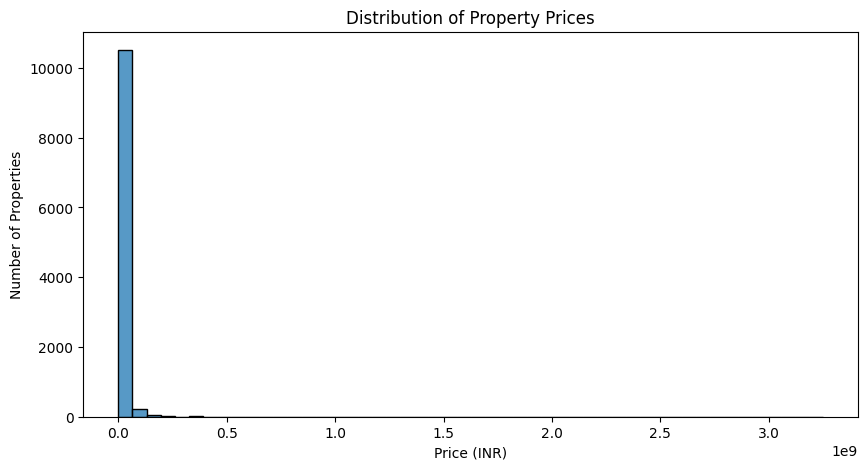

In [ ]:
# =====================================
# Distribution of Property Prices
# =====================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(df_sale['exactPrice'], bins=50)

plt.title('Distribution of Property Prices')
plt.xlabel('Price (INR)')
plt.ylabel('Number of Properties')

plt.show()

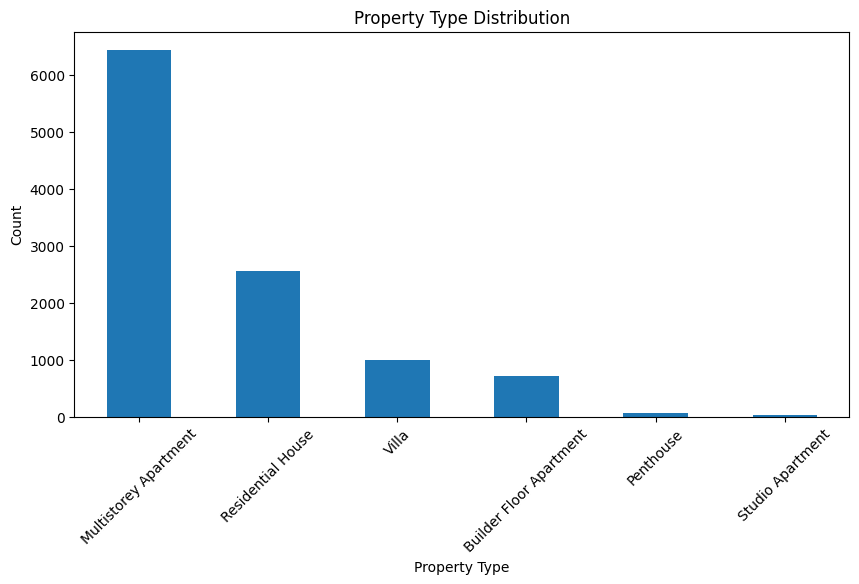

In [ ]:
# =====================================
# Property Type Distribution
# =====================================

plt.figure(figsize=(10,5))

df_sale['propertyType'].value_counts().plot(kind='bar')

plt.title('Property Type Distribution')
plt.xlabel('Property Type')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

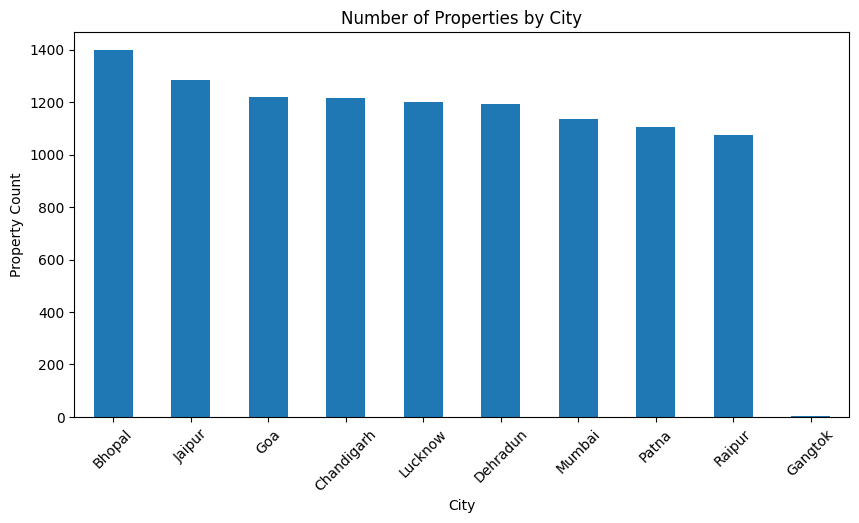

In [ ]:
# =====================================
# Properties by City
# =====================================

plt.figure(figsize=(10,5))

df_sale['city'].value_counts().plot(kind='bar')

plt.title('Number of Properties by City')
plt.xlabel('City')
plt.ylabel('Property Count')

plt.xticks(rotation=45)

plt.show()

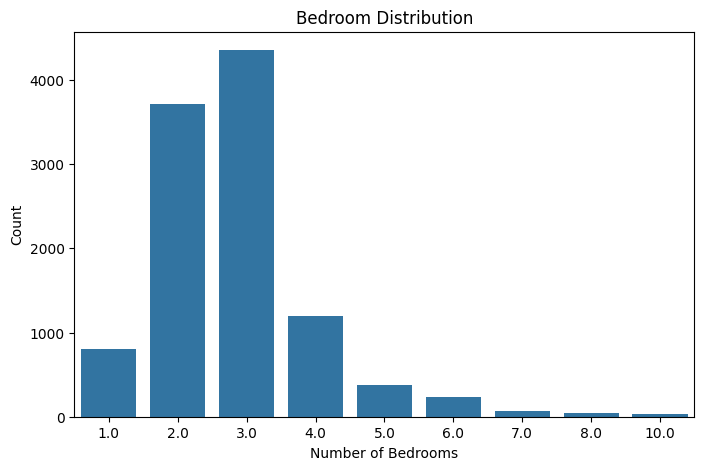

In [ ]:
# =====================================
# Bedroom Distribution
# =====================================

plt.figure(figsize=(8,5))

sns.countplot(x='bedrooms', data=df_sale)

plt.title('Bedroom Distribution')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Count')

plt.show()

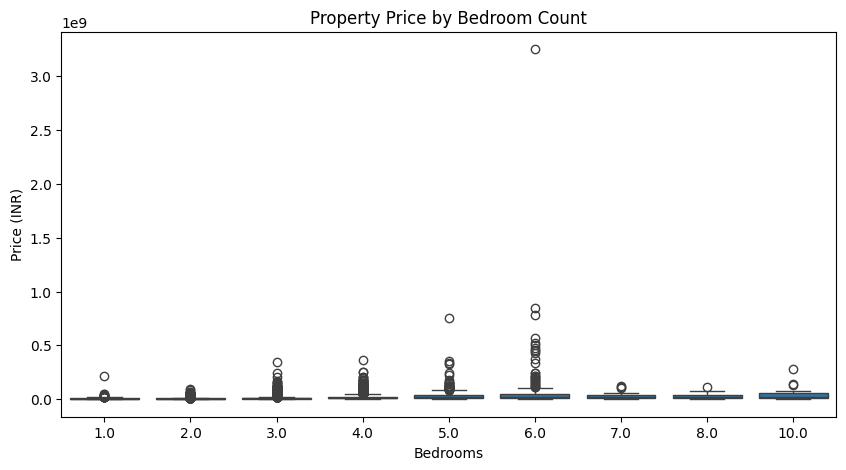

In [ ]:
# =====================================
# Price by Bedroom Count
# =====================================

plt.figure(figsize=(10,5))

sns.boxplot(
    x='bedrooms',
    y='exactPrice',
    data=df_sale
)

plt.title('Property Price by Bedroom Count')
plt.xlabel('Bedrooms')
plt.ylabel('Price (INR)')

plt.show()

In [ ]:
# Top property types

print(df_sale['propertyType'].value_counts())

propertyType
Multistorey Apartment      6443
Residential House          2568
Villa                       998
Builder Floor Apartment     714
Penthouse                    63
Studio Apartment             37
Name: count, dtype: int64


In [ ]:
# Average price by city

print(
    df_sale.groupby('city')['exactPrice']
    .mean()
    .sort_values(ascending=False)
)

city
Mumbai        3.459922e+07
Chandigarh    2.548325e+07
Goa           1.871215e+07
Dehradun      9.948961e+06
Lucknow       9.856774e+06
Patna         9.114412e+06
Jaipur        7.786979e+06
Raipur        5.930485e+06
Gangtok       5.600000e+06
Bhopal        5.463045e+06
Name: exactPrice, dtype: float64


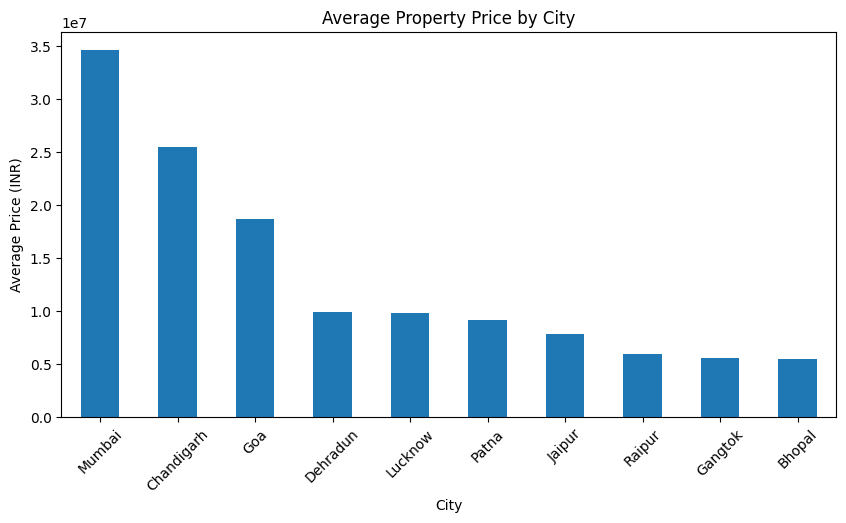

In [ ]:
# =====================================
# Average Property Price by City
# =====================================

plt.figure(figsize=(10,5))

df_sale.groupby('city')['exactPrice'] \
       .mean() \
       .sort_values(ascending=False) \
       .plot(kind='bar')

plt.title('Average Property Price by City')
plt.xlabel('City')
plt.ylabel('Average Price (INR)')

plt.xticks(rotation=45)

plt.show()

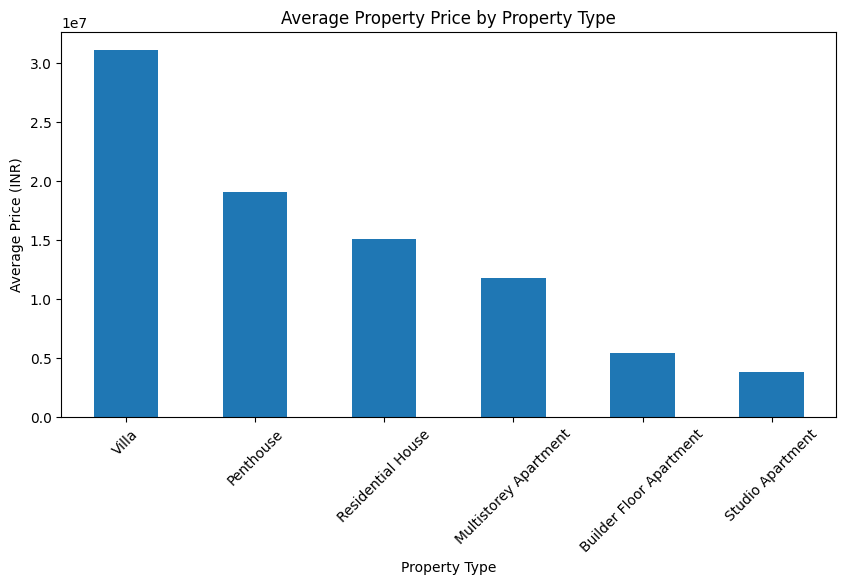

In [ ]:
# =====================================
# Average Price by Property Type
# =====================================

plt.figure(figsize=(10,5))

df_sale.groupby('propertyType')['exactPrice'] \
       .mean() \
       .sort_values(ascending=False) \
       .plot(kind='bar')

plt.title('Average Property Price by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Average Price (INR)')

plt.xticks(rotation=45)

plt.show()

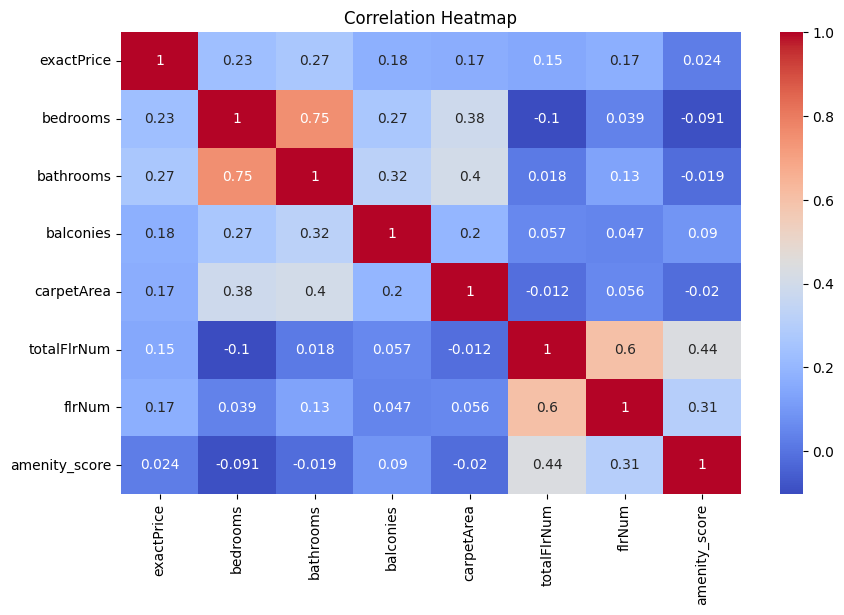

In [ ]:
# =====================================
# Correlation Heatmap
# =====================================

import seaborn as sns

numeric_cols = [
    'exactPrice',
    'bedrooms',
    'bathrooms',
    'balconies',
    'carpetArea',
    'totalFlrNum',
    'flrNum',
    'amenity_score'
]

plt.figure(figsize=(10,6))

sns.heatmap(
    df_sale[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

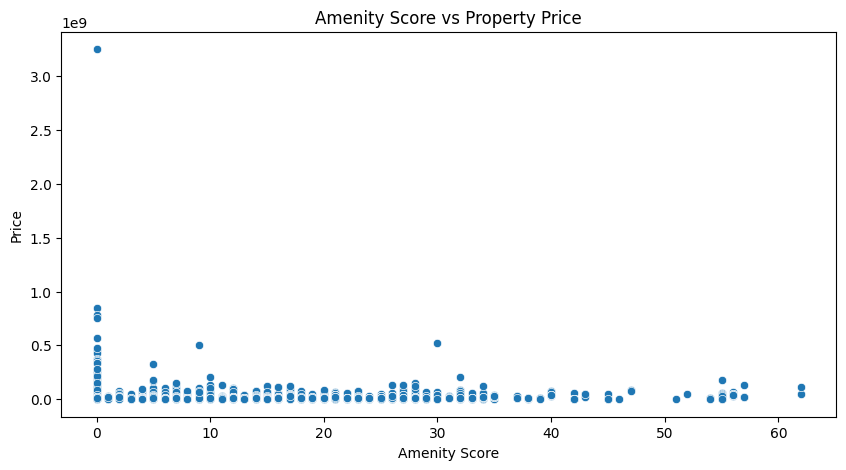

In [ ]:
# =====================================
# Amenity Score vs Price
# =====================================

plt.figure(figsize=(10,5))

sns.scatterplot(
    x='amenity_score',
    y='exactPrice',
    data=df_sale
)

plt.title('Amenity Score vs Property Price')
plt.xlabel('Amenity Score')
plt.ylabel('Price')

plt.show()

In [95]:
# Check categorical columns

cat_cols = df_sale.select_dtypes(include='object').columns

print(cat_cols)

Index(['propertyType', 'postedOn', 'maintenanceChargesFrequency', 'locality',
       'furnishing', 'facing', 'city', 'carpetAreaUnit', 'brokerage'],
      dtype='object')


In [ ]:
# Final validation checks

print(df_sale.shape)

print("Duplicates:", df_sale.duplicated().sum())

print("Missing values:", df_sale.isnull().sum().sum())

print(df_sale.describe())

(10823, 86)
Duplicates: 32
Missing values: 0
         exactPrice     noOfLifts        flrNum   totalFlrNum    carpetArea  \
count  1.082300e+04  10823.000000  10823.000000  10823.000000  10823.000000   
mean   1.394028e+07      2.067449      4.940774      6.699344   1095.059041   
std    4.194325e+07      0.648183      5.292402      9.389947    660.785399   
min    1.000000e+05      1.000000     -1.000000      1.000000      1.000000   
25%    4.200000e+06      2.000000      1.000000      2.000000    950.000000   
50%    6.900000e+06      2.000000      3.000000      4.000000   1000.000000   
75%    1.250000e+07      2.000000      9.000000      7.000000   1100.000000   
max    3.250000e+09     10.000000     70.000000    200.000000   9102.000000   

           bedrooms     bathrooms     balconies  Water_Storage  \
count  10823.000000  10823.000000  10823.000000   10823.000000   
mean       2.818257      2.586159      2.084819       0.101543   
std        1.178549      1.102634      0.8573

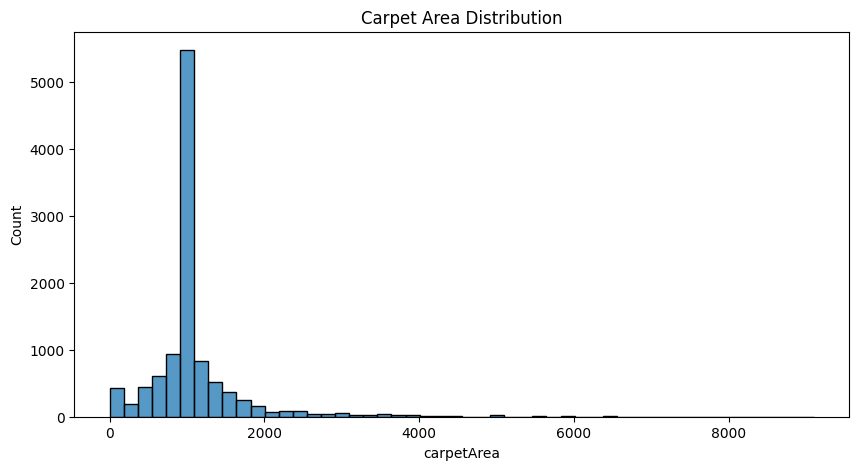

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df_sale['carpetArea'], bins=50)

plt.title("Carpet Area Distribution")

plt.show()

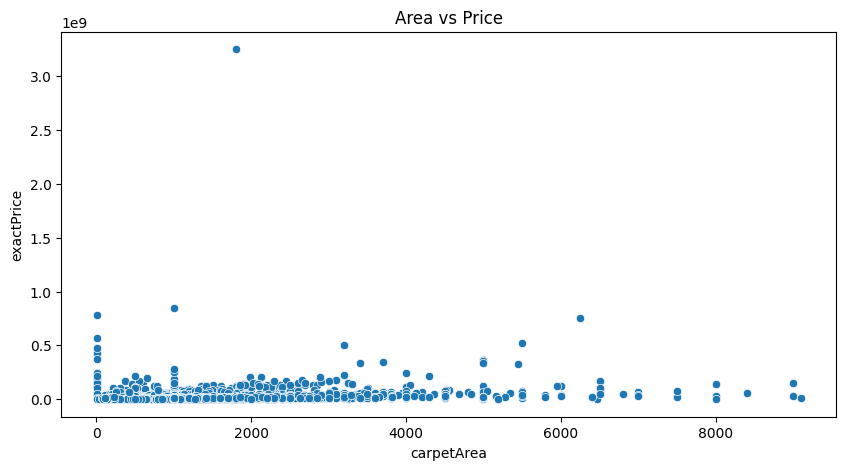

In [ ]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x='carpetArea',
    y='exactPrice',
    data=df_sale
)

plt.title('Area vs Price')

plt.show()

<Axes: xlabel='propertyType', ylabel='exactPrice'>

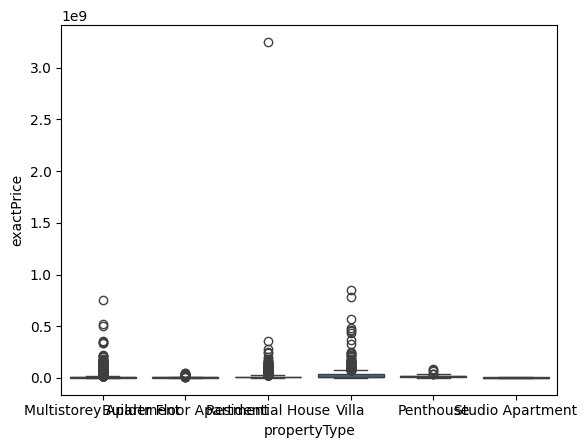

In [ ]:
sns.boxplot(
    x='propertyType',
    y='exactPrice',
    data=df_sale
)

In [ ]:
df_sale['postedOn'].head()

,postedOn
11936,"Jun 04, '23"
11937,"Jun 28, '23"
11938,"Jul 02, '23"
11939,"Jun 30, '23"
11940,"Jul 01, '23"


In [96]:
# =====================================
# Convert postedOn to datetime
# =====================================

df_sale['postedOn'] = pd.to_datetime(
    df_sale['postedOn'],
    format="%b %d, '%y"
)

# Extract date components

df_sale['posted_year'] = df_sale['postedOn'].dt.year
df_sale['posted_month'] = df_sale['postedOn'].dt.month
df_sale['posted_day'] = df_sale['postedOn'].dt.day

# Check

df_sale[['postedOn','posted_year','posted_month','posted_day']].head()

,postedOn,posted_year,posted_month,posted_day
11936,2023-06-04,2023,6,4
11937,2023-06-28,2023,6,28
11938,2023-07-02,2023,7,2
11939,2023-06-30,2023,6,30
11940,2023-07-01,2023,7,1


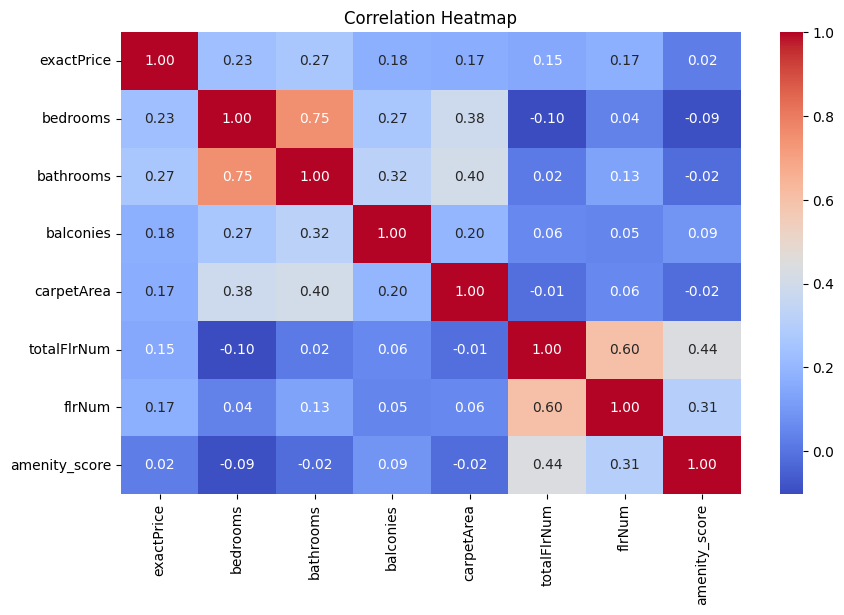

In [ ]:
# =====================================
# Correlation Heatmap
# =====================================

import matplotlib.pyplot as plt
import seaborn as sns

corr_cols = [
    'exactPrice',
    'bedrooms',
    'bathrooms',
    'balconies',
    'carpetArea',
    'totalFlrNum',
    'flrNum',
    'amenity_score'
]

plt.figure(figsize=(10,6))

sns.heatmap(
    df_sale[corr_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

In [97]:
# =====================================
# Correlation with Price
# =====================================

numeric_df = df_sale.select_dtypes(
    include=['int64','float64']
)

corr_target = numeric_df.corr()['exactPrice'] \
                        .sort_values(ascending=False)

print(corr_target.head(20))

exactPrice                              1.000000
bathrooms                               0.254719
bedrooms                                0.214872
balconies                               0.177894
carpetArea                              0.170089
totalFlrNum                             0.158303
flrNum                                  0.144461
noOfLifts                               0.111345
Barbeque_Pit                            0.054198
Multipurpose_Courts                     0.045205
Mini_Cinema_Theatre                     0.042583
Bank__And__ATM                          0.041601
Meditation_Area                         0.041429
Event_Space__And__Amphitheatre          0.039174
Library_And_Business_Centre             0.038819
Concierge_Services                      0.037458
amenity_score                           0.037327
Indoor_Squash__And__Badminton_Courts    0.037055
Coffee_Lounge__And__Restaurants         0.037023
Laundry_Service                         0.035885
Name: exactPrice, dt

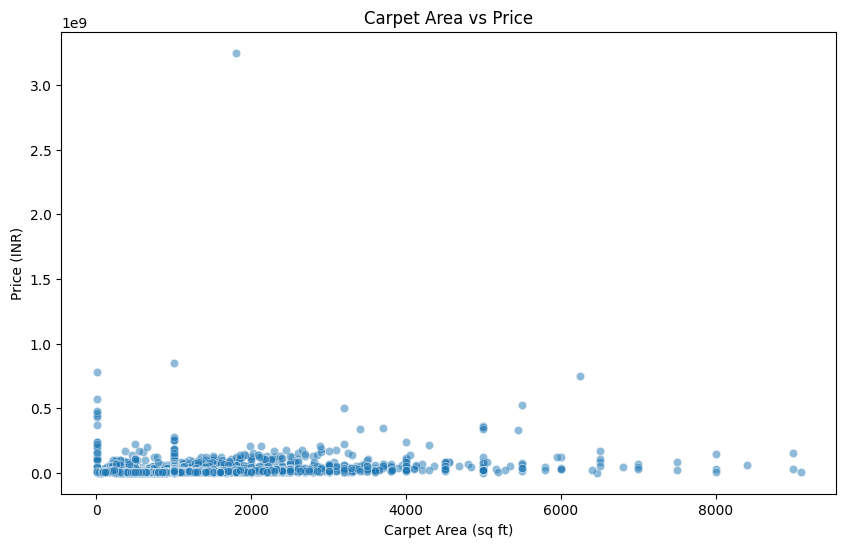

In [ ]:
# =====================================
# Carpet Area vs Price
# =====================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='carpetArea',
    y='exactPrice',
    data=df_sale,
    alpha=0.5
)

plt.title('Carpet Area vs Price')

plt.xlabel('Carpet Area (sq ft)')
plt.ylabel('Price (INR)')

plt.show()

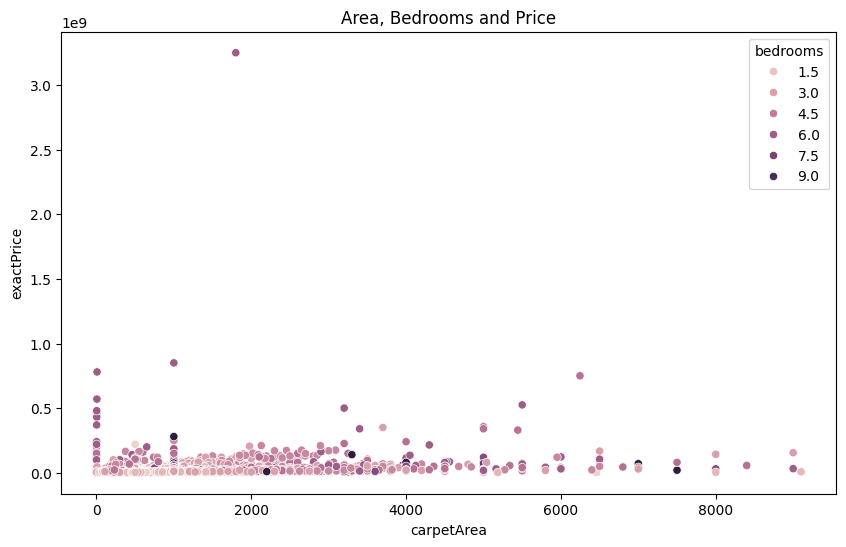

In [ ]:
# =====================================
# Bedrooms, Area and Price
# =====================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='carpetArea',
    y='exactPrice',
    hue='bedrooms',
    data=df_sale
)

plt.title('Area, Bedrooms and Price')

plt.show()

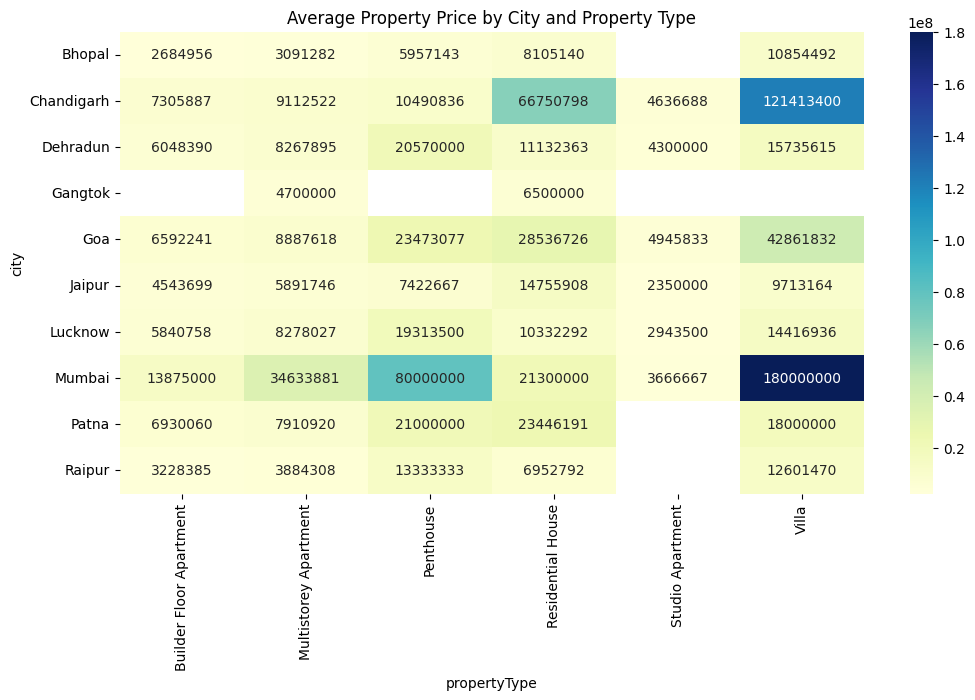

In [ ]:
# =====================================
# Average Price by City and Property Type
# =====================================

pivot_table = pd.pivot_table(
    df_sale,
    values='exactPrice',
    index='city',
    columns='propertyType',
    aggfunc='mean'
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title('Average Property Price by City and Property Type')

plt.show()

In [ ]:
print(df_sale['posted_year'].value_counts())

posted_year
2023    10791
2022       13
2021        7
2019        6
2020        5
2018        1
Name: count, dtype: int64


In [98]:
numeric_df = df_sale.select_dtypes(include=['int64','float64'])

corr_target = numeric_df.corr()['exactPrice'] \
                        .sort_values(ascending=False)

print(corr_target.head(20))

exactPrice                              1.000000
bathrooms                               0.254719
bedrooms                                0.214872
balconies                               0.177894
carpetArea                              0.170089
totalFlrNum                             0.158303
flrNum                                  0.144461
noOfLifts                               0.111345
Barbeque_Pit                            0.054198
Multipurpose_Courts                     0.045205
Mini_Cinema_Theatre                     0.042583
Bank__And__ATM                          0.041601
Meditation_Area                         0.041429
Event_Space__And__Amphitheatre          0.039174
Library_And_Business_Centre             0.038819
Concierge_Services                      0.037458
amenity_score                           0.037327
Indoor_Squash__And__Badminton_Courts    0.037055
Coffee_Lounge__And__Restaurants         0.037023
Laundry_Service                         0.035885
Name: exactPrice, dt

In [99]:
df_sale.drop(columns=['posted_year'], inplace=True)

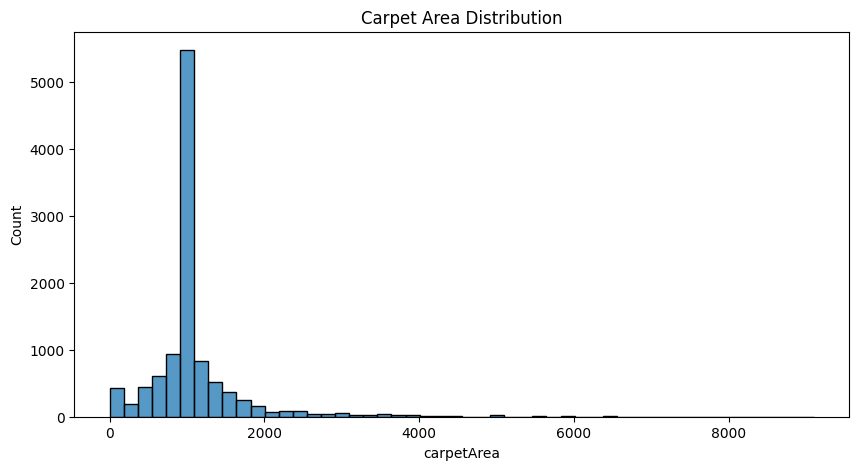

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df_sale['carpetArea'],
    bins=50
)

plt.title("Carpet Area Distribution")

plt.show()

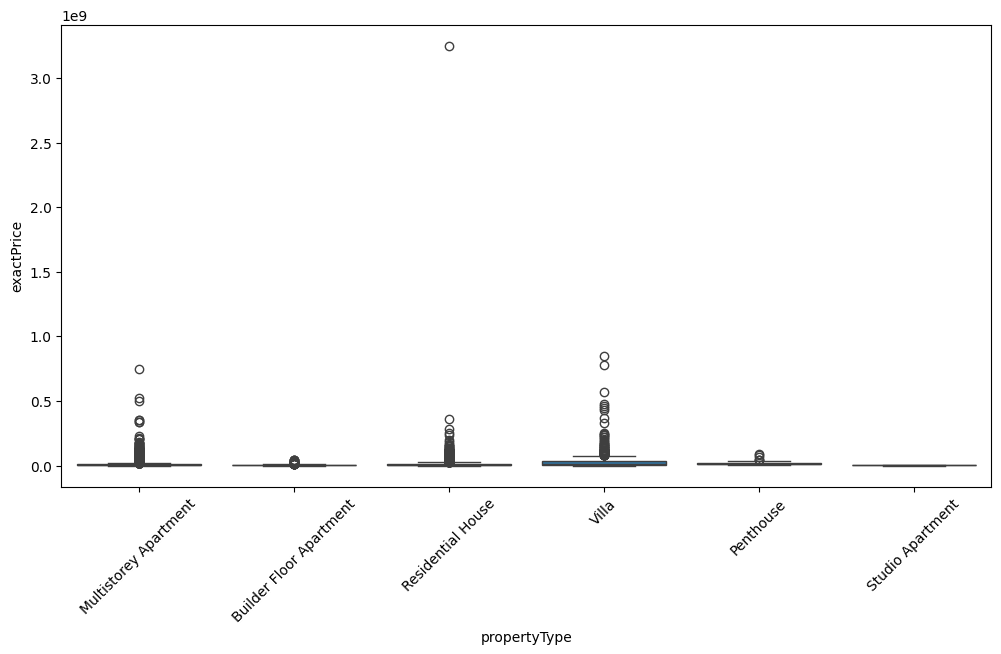

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='propertyType',
    y='exactPrice',
    data=df_sale
)

plt.xticks(rotation=45)

plt.show()


In [100]:
corr_target = (
    df_sale.select_dtypes(include=['int64','float64'])
    .corr()['exactPrice']
    .sort_values(ascending=False)
)

print(corr_target.head(20))

exactPrice                              1.000000
bathrooms                               0.254719
bedrooms                                0.214872
balconies                               0.177894
carpetArea                              0.170089
totalFlrNum                             0.158303
flrNum                                  0.144461
noOfLifts                               0.111345
Barbeque_Pit                            0.054198
Multipurpose_Courts                     0.045205
Mini_Cinema_Theatre                     0.042583
Bank__And__ATM                          0.041601
Meditation_Area                         0.041429
Event_Space__And__Amphitheatre          0.039174
Library_And_Business_Centre             0.038819
Concierge_Services                      0.037458
amenity_score                           0.037327
Indoor_Squash__And__Badminton_Courts    0.037055
Coffee_Lounge__And__Restaurants         0.037023
Laundry_Service                         0.035885
Name: exactPrice, dt

In [101]:
print(df_sale['exactPrice'].skew())

df_sale['log_price'] = np.log1p(df_sale['exactPrice'])

print(df_sale['log_price'].skew())

47.592800152657425
-2.7409357150522853


In [102]:
for col in [
    'city',
    'propertyType',
    'locality',
    'furnishing',
    'facing'
]:
    print(col, ":", df_sale[col].nunique())

city : 10
propertyType : 6
locality : 1613
furnishing : 4
facing : 9


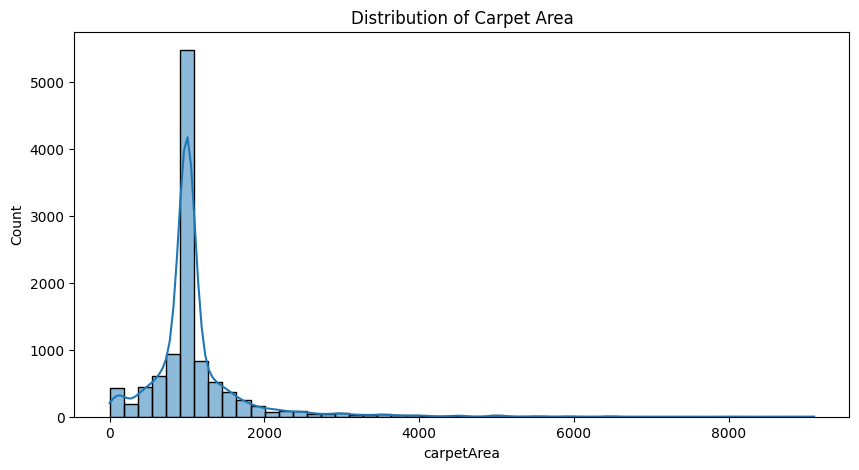

In [ ]:
# Distribution of carpet area

plt.figure(figsize=(10,5))

sns.histplot(
    df_sale['carpetArea'],
    bins=50,
    kde=True
)

plt.title("Distribution of Carpet Area")

plt.show()

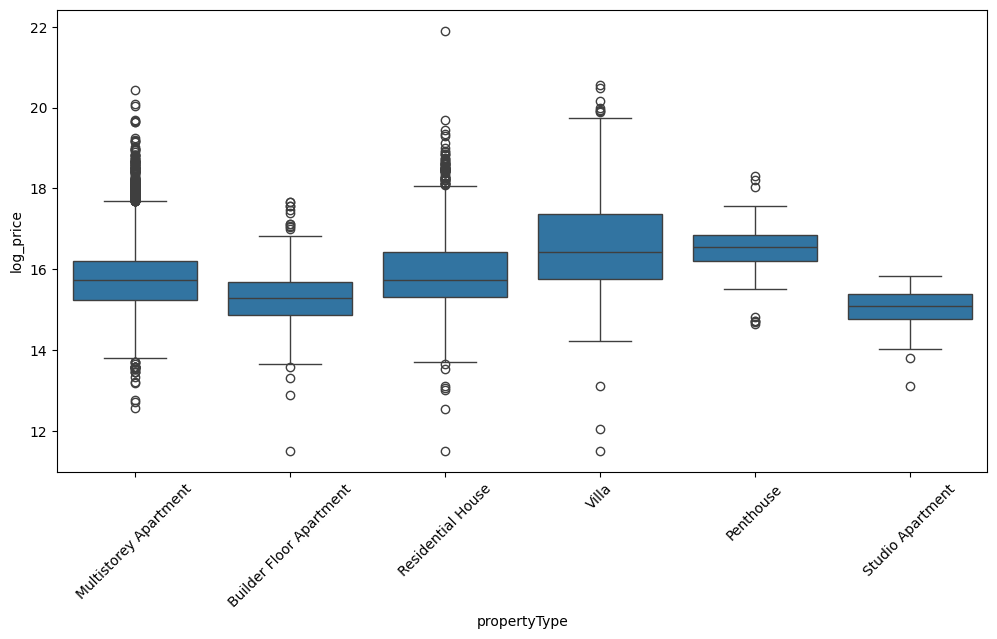

In [ ]:
# Property type vs price

plt.figure(figsize=(12,6))

sns.boxplot(
    x='propertyType',
    y='log_price',   # use log price
    data=df_sale
)

plt.xticks(rotation=45)

plt.show()

In [103]:
# Number of records per locality

locality_counts = df_sale['locality'].value_counts()

print(locality_counts.describe())

print("\nTop 20 localities:")
print(locality_counts.head(20))

count    1613.000000
mean        7.342219
std        29.218450
min         1.000000
25%         1.000000
50%         2.000000
75%         6.000000
max       822.000000
Name: count, dtype: float64

Top 20 localities:
locality
9                         822
Zirakpur                  685
Sahastradhara Road        180
Hoshangabad Road          135
Jagatpura                 132
Ajmer Road                124
Kolar Road Janki Nagar    111
Vaishali Nagar            108
Danapur                    93
Faizabad Road              89
Katara Hills               86
Bailey Road                86
Shankar Nagar              84
Porvorim                   80
Mansarovar                 76
Dera Bassi                 73
Saguna More                68
Gola Road                  68
Mansarovar Extension       65
Saddu                      55
Name: count, dtype: int64


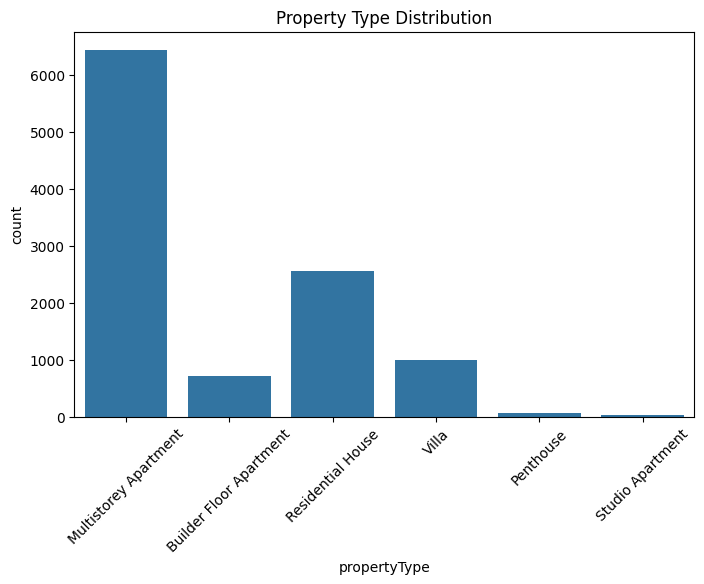

In [ ]:
# =====================================
# Property Type Count
# =====================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df_sale,
    x='propertyType'
)

plt.xticks(rotation=45)

plt.title("Property Type Distribution")

plt.show()

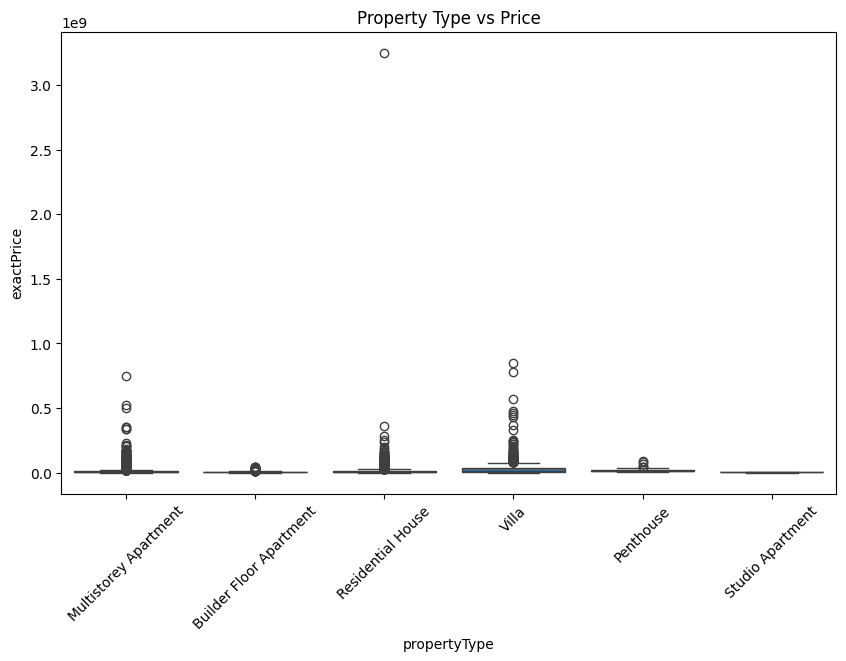

In [ ]:
# =====================================
# Property Type vs Price
# =====================================

plt.figure(figsize=(10,6))

sns.boxplot(
    x='propertyType',
    y='exactPrice',
    data=df_sale
)

plt.xticks(rotation=45)

plt.title("Property Type vs Price")

plt.show()

In [104]:
(df_sale['locality'] == '9').sum()

np.int64(822)

In [105]:
missing_percent = (
    df_sale.isnull().sum()
    / len(df_sale)
    * 100
)

missing_percent[
    missing_percent > 0
].sort_values(ascending=False)

,0


In [106]:
for col in [
    'carpetArea',
    'sqftPrice',
    'balconies'
]:
    print("\n", col)
    print((df_sale[col] == 9).sum())


 carpetArea
0

 sqftPrice


KeyError: 'sqftPrice'

In [107]:
# Replace fake locality with NaN
df_sale['locality'] = df_sale['locality'].replace('9', np.nan)

In [108]:
df_sale['locality'].isnull().sum()

np.int64(822)

In [109]:
print(df_sale.columns.tolist())

['exactPrice', 'propertyType', 'postedOn', 'noOfLifts', 'maintenanceChargesFrequency', 'locality', 'furnishing', 'flrNum', 'facing', 'totalFlrNum', 'city', 'carpetAreaUnit', 'carpetArea', 'brokerage', 'bedrooms', 'bathrooms', 'balconies', 'Water_Storage', 'Waste_Disposal', 'Visitor_Parking', 'Vaastu_Compliant', 'Swimming_Pool', 'Skydeck', 'Service_Or_Goods_Lift', 'Security', 'Retail_Boulevard___Retail_Shops__', 'Reserved_Parking', 'Rentable_Community_Space', 'Recreational_Pool', 'Rain_Water_Harvesting', 'RO_Water_System', 'Private_Terrace_Or_Garden', 'Private_Garden', 'Power_Back_Up', 'Piped_Gas', 'Park', 'Outdoor_Tennis_Courts', 'Multipurpose_Hall', 'Multipurpose_Courts', 'Mini_Cinema_Theatre', 'Meditation_Area', 'Maintenance_Staff', 'Long', 'Lift', 'Library_And_Business_Centre', 'Library', 'Laundry_Service', 'Lat', 'Kids_Play_Pool_With_Water_Slides', 'Kids_Play_Area', 'Kids_Club', 'Jogging_and_Strolling_Track', 'Internet_Or_Wi_Fi_Connectivity', 'Intercom_Facility', 'Indoor_Squash__An

In [110]:
for col in [
    'carpetArea',
    'balconies',
    'bedrooms',
    'bathrooms',
    'amenity_score'
]:
    print(f"\n{col}")
    print((df_sale[col] == 9).sum())


carpetArea
0

balconies
0

bedrooms
0

bathrooms
0

amenity_score
156


In [111]:
print(df_sale.shape)

(11843, 89)


In [112]:
print(df_sale['amenity_score'].value_counts().head(20))

amenity_score
0.0     8770
4.0      209
12.0     202
13.0     195
9.0      156
7.0      148
8.0      146
16.0     136
6.0      135
10.0     123
14.0     118
5.0      109
17.0     104
11.0     102
21.0      99
19.0      92
15.0      89
20.0      85
3.0       82
18.0      72
Name: count, dtype: int64


In [ ]:
print(df_sale[['Lat','Long']].isnull().sum())

Lat     0
Long    0
dtype: int64


In [116]:
# =====================================
# Save Cleaned Dataset
# =====================================

df_sale.to_csv(
    "cleaned_real_estate.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [113]:
df_sale['log_price'] = np.log1p(df_sale['exactPrice'])

In [114]:
categorical_cols = df_sale.select_dtypes(include='object').columns

print(categorical_cols)

for col in categorical_cols:
    print("\n", col)
    print(df_sale[col].nunique())

Index(['propertyType', 'maintenanceChargesFrequency', 'locality', 'furnishing',
       'facing', 'city', 'carpetAreaUnit', 'brokerage'],
      dtype='object')

 propertyType
6

 maintenanceChargesFrequency
6

 locality
1612

 furnishing
4

 facing
9

 city
10

 carpetAreaUnit
8

 brokerage
11


In [117]:
from google.colab import files

files.download("cleaned_real_estate.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [118]:
for col in [
    'maintenanceChargesFrequency',
    'carpetAreaUnit',
    'brokerage'
]:
    print("\n" + "="*50)
    print(col)
    print(df_sale[col].value_counts(dropna=False))


maintenanceChargesFrequency
maintenanceChargesFrequency
9                       9836
Monthly                 1767
Per sq. Unit Monthly     174
Yearly                    36
One-Time                  27
Quarterly                  3
Name: count, dtype: int64

carpetAreaUnit
carpetAreaUnit
Sq-ft     5948
9         5332
Sq-m       388
Sq-yrd     125
Kanal       25
Marla       23
Acre         1
Biswa1       1
Name: count, dtype: int64

brokerage
brokerage
9               9494
No Brokerage    1253
1%               747
2%               328
1.5%               9
0.25%              4
0.75%              3
0.5%               2
4%                 1
3%                 1
5%                 1
Name: count, dtype: int64


In [119]:
# Replace placeholder with NaN
df_sale['maintenanceChargesFrequency'] = (
    df_sale['maintenanceChargesFrequency']
    .replace('9', np.nan)
)

In [120]:
# Number of localities appearing less than 5 times
locality_counts = df_sale['locality'].value_counts()

print(
    (locality_counts < 5).sum()
)

print(
    ((locality_counts < 5).sum() /
     len(locality_counts)) * 100
)

1071
66.43920595533498


In [121]:
# =====================================
# Drop Unnecessary Features
# =====================================

drop_cols = [
    'postedOn',
    'maintenanceChargesFrequency',
    'carpetAreaUnit',
    'brokerage',
    'locality'
]

df_sale.drop(columns=drop_cols, inplace=True)

print(df_sale.shape)

(11843, 84)


In [122]:
# =====================================
# One-Hot Encoding
# =====================================

# Convert categorical variables into dummy variables

df_encoded = pd.get_dummies(
    df_sale,
    columns=[
        'propertyType',
        'furnishing',
        'facing',
        'city'
    ],
    drop_first=True
)

print("Shape after encoding:")
print(df_encoded.shape)

Shape after encoding:
(11843, 105)


In [123]:
numeric_cols = df_encoded.select_dtypes(
    include=['int64','float64']
).columns

print(len(numeric_cols))
print(numeric_cols)

78
Index(['exactPrice', 'noOfLifts', 'flrNum', 'totalFlrNum', 'carpetArea',
       'bedrooms', 'bathrooms', 'balconies', 'Water_Storage', 'Waste_Disposal',
       'Visitor_Parking', 'Vaastu_Compliant', 'Swimming_Pool', 'Skydeck',
       'Service_Or_Goods_Lift', 'Security',
       'Retail_Boulevard___Retail_Shops__', 'Reserved_Parking',
       'Rentable_Community_Space', 'Recreational_Pool',
       'Rain_Water_Harvesting', 'RO_Water_System', 'Private_Terrace_Or_Garden',
       'Private_Garden', 'Power_Back_Up', 'Piped_Gas', 'Park',
       'Outdoor_Tennis_Courts', 'Multipurpose_Hall', 'Multipurpose_Courts',
       'Mini_Cinema_Theatre', 'Meditation_Area', 'Maintenance_Staff', 'Long',
       'Lift', 'Library_And_Business_Centre', 'Library', 'Laundry_Service',
       'Lat', 'Kids_Play_Pool_With_Water_Slides', 'Kids_Play_Area',
       'Kids_Club', 'Jogging_and_Strolling_Track',
       'Internet_Or_Wi_Fi_Connectivity', 'Intercom_Facility',
       'Indoor_Squash__And__Badminton_Courts', 'Indo

In [124]:
# =====================================
# Define Features and Target
# =====================================

# Target variable
y = df_encoded['log_price']

# Remove target-related columns from features
X = df_encoded.drop(
    columns=[
        'exactPrice',
        'log_price'
    ]
)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (11843, 103)
Target shape: (11843,)


In [ ]:
# =====================================
# Save Encoded Dataset
# =====================================

df_encoded.to_csv(
    "encoded_real_estate.csv",
    index=False
)

print("Encoded dataset saved.")

Encoded dataset saved.


In [ ]:
print(df_sale.shape)

(10823, 89)


In [ ]:
from google.colab import files

files.download("encoded_real_estate.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [125]:
# =====================================
# Feature Scaling
# =====================================

from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_encoded.drop(columns=['exactPrice', 'log_price'])
y = df_encoded['log_price']

# Initialize scaler
scaler = StandardScaler()

# Scale features
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (11843, 103)


In [126]:
# =====================================
# Save Scaled Dataset
# =====================================

scaled_df = X_scaled.copy()
scaled_df['log_price'] = y.values

scaled_df.to_csv(
    "scaled_real_estate.csv",
    index=False
)

print("Scaled dataset saved successfully.")

Scaled dataset saved successfully.


In [ ]:
from google.colab import files

files.download("scaled_real_estate.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [127]:
# =====================================
# Correlation with Target
# =====================================

corr_target = (
    df_encoded.corr(numeric_only=True)['log_price']
    .abs()
    .sort_values(ascending=False)
)

print(corr_target.head(30))

log_price                         1.000000
posted_day                        0.276358
exactPrice                        0.192304
facing_East                       0.178015
city_Mumbai                       0.175099
city_Patna                        0.163637
Security                          0.157430
amenity_score                     0.155568
Gymnasium                         0.154890
Swimming_Pool                     0.147295
Lift                              0.145185
totalFlrNum                       0.143588
Power_Back_Up                     0.138442
flrNum                            0.137526
Club_House                        0.136355
bathrooms                         0.136150
Reserved_Parking                  0.130673
carpetArea                        0.128261
Rain_Water_Harvesting             0.121852
Park                              0.121632
Fire_Fighting_Equipment           0.120272
Intercom_Facility                 0.111961
facing_North - East               0.111454
Visitor_Par

In [128]:
# =====================================
# Train-Test Split
# =====================================

from sklearn.model_selection import train_test_split

# Features and target
X = df_encoded.drop(columns=['exactPrice', 'log_price'])
y = df_encoded['log_price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (9474, 103)
Testing set : (2369, 103)


In [129]:
!pip install xgboost lightgbm catboost -q

In [218]:
# =====================================
# Evaluation Function
# =====================================

import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, y_pred)

    return [mae, mse, rmse, r2]

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr_results = evaluate_model(
    lr,
    X_train,
    X_test,
    y_train,
    y_test
)

print(lr_results)

[0.36188351111876554, 0.24113270749955468, np.float64(0.49105265247176366), 0.7126007607919069]


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_results = evaluate_model(
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

print(rf_results)

[0.28157633402402227, 0.1720672541016861, np.float64(0.4148099011615876), 0.794917917049716]


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    random_state=42
)

gbr_results = evaluate_model(
    gbr,
    X_train,
    X_test,
    y_train,
    y_test
)

print(gbr_results)

[0.31646117646543054, 0.189688214651795, np.float64(0.43553210519064495), 0.7739159936328089]


In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_results = evaluate_model(
    xgb,
    X_train,
    X_test,
    y_train,
    y_test
)

print(xgb_results)

[0.2732193376563537, 0.15310414313266127, np.float64(0.3912852452273932), 0.8175195115079313]


In [ ]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    random_state=42
)

lgbm_results = evaluate_model(
    lgbm,
    X_train,
    X_test,
    y_train,
    y_test
)

print(lgbm_results)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006496 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1177
[LightGBM] [Info] Number of data points in the train set: 8658, number of used features: 101
[LightGBM] [Info] Start training from score 15.855425
[0.28188261458519515, 0.1581017522288673, np.float64(0.39762011044320594), 0.8115630028824405]


In [219]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    verbose=0,
    random_state=42
)

cat_results = evaluate_model(
    cat,
    X_train,
    X_test,
    y_train,
    y_test
)

print(cat_results)

[0.6763216680897802, 3.134445413212888, np.float64(1.770436503581218), 0.8501124973596442]


In [ ]:
import pandas as pd

# Model evaluation results
results = {
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],

    "MAE": [
        0.361883,
        0.281576,
        0.316461,
        0.273219,
        0.281883,
        0.267095
    ],

    "MSE": [
        0.241133,
        0.172067,
        0.189688,
        0.153104,
        0.158102,
        0.144424
    ],

    "RMSE": [
        0.491053,
        0.414810,
        0.435532,
        0.391285,
        0.397620,
        0.380031
    ],

    "R2 Score": [
        0.712601,
        0.794918,
        0.773916,
        0.817520,
        0.811563,
        0.827865
    ]
}

comparison_df = pd.DataFrame(results)

# Sort by R²
comparison_df = comparison_df.sort_values(
    by="R2 Score",
    ascending=False
)

comparison_df.reset_index(drop=True, inplace=True)

print(comparison_df)

               Model       MAE       MSE      RMSE  R2 Score
0           CatBoost  0.267095  0.144424  0.380031  0.827865
1            XGBoost  0.273219  0.153104  0.391285  0.817520
2           LightGBM  0.281883  0.158102  0.397620  0.811563
3      Random Forest  0.281576  0.172067  0.414810  0.794918
4  Gradient Boosting  0.316461  0.189688  0.435532  0.773916
5  Linear Regression  0.361883  0.241133  0.491053  0.712601


In [57]:
type(X_train)

pandas.core.frame.DataFrame

In [ ]:
print(y_train.name)

log_price


In [132]:
# Import library
from catboost import CatBoostRegressor

# Final selected model
final_model = CatBoostRegressor(
    random_state=42,
    verbose=0
)

# Train on training data
final_model.fit(X_train, y_train)

print("Final model trained successfully.")

Final model trained successfully.


In [133]:
import joblib

# Save trained model
joblib.dump(
    final_model,
    "catboost_real_estate_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [134]:
print(X_train.shape)
print(X_train.columns.tolist())

(9474, 103)
['noOfLifts', 'flrNum', 'totalFlrNum', 'carpetArea', 'bedrooms', 'bathrooms', 'balconies', 'Water_Storage', 'Waste_Disposal', 'Visitor_Parking', 'Vaastu_Compliant', 'Swimming_Pool', 'Skydeck', 'Service_Or_Goods_Lift', 'Security', 'Retail_Boulevard___Retail_Shops__', 'Reserved_Parking', 'Rentable_Community_Space', 'Recreational_Pool', 'Rain_Water_Harvesting', 'RO_Water_System', 'Private_Terrace_Or_Garden', 'Private_Garden', 'Power_Back_Up', 'Piped_Gas', 'Park', 'Outdoor_Tennis_Courts', 'Multipurpose_Hall', 'Multipurpose_Courts', 'Mini_Cinema_Theatre', 'Meditation_Area', 'Maintenance_Staff', 'Long', 'Lift', 'Library_And_Business_Centre', 'Library', 'Laundry_Service', 'Lat', 'Kids_Play_Pool_With_Water_Slides', 'Kids_Play_Area', 'Kids_Club', 'Jogging_and_Strolling_Track', 'Internet_Or_Wi_Fi_Connectivity', 'Intercom_Facility', 'Indoor_Squash__And__Badminton_Courts', 'Indoor_Games_Room', 'Health_club_with_Steam__Or__Jaccuzi', 'Gymnasium', 'Guest_Accommodation', 'Grand_Entrance_lo

In [135]:
import joblib

joblib.dump(
    final_model,
    "catboost_real_estate_model.pkl"
)

['catboost_real_estate_model.pkl']

In [136]:
from google.colab import files

files.download("catboost_real_estate_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [137]:
print(df.columns.tolist())

['exactPrice', 'sqftPrice', 'securityDeposit', 'propertyType', 'postedOn', 'noOfLifts', 'maintenanceChargesFrequency', 'maintenanceCharges', 'locality', 'furnishing', 'flrNum', 'firstMonthCharges', 'facing', 'totalFlrNum', 'city', 'carpetAreaUnit', 'carpetArea', 'brokerage', 'bedrooms', 'bathrooms', 'balconies', 'Water_Storage', 'Waste_Disposal', 'Visitor_Parking', 'Vaastu_Compliant', 'URLs', 'Swimming_Pool', 'Skydeck', 'Service_Or_Goods_Lift', 'Security', 'Retail_Boulevard___Retail_Shops__', 'Reserved_Parking', 'Rentable_Community_Space', 'RentOrSale', 'Recreational_Pool', 'Rain_Water_Harvesting', 'RO_Water_System', 'Private_Terrace_Or_Garden', 'Private_Garden', 'Power_Back_Up', 'Piped_Gas', 'Park', 'Outdoor_Tennis_Courts', 'Multipurpose_Hall', 'Multipurpose_Courts', 'Mini_Cinema_Theatre', 'Meditation_Area', 'Maintenance_Staff', 'Long', 'Lift', 'Library_And_Business_Centre', 'Library', 'Laundry_Service', 'Lat', 'Kids_Play_Pool_With_Water_Slides', 'Kids_Play_Area', 'Kids_Club', 'Joggin

                            Feature  Importance
2                       totalFlrNum   30.658428
1                            flrNum   23.130518
75                    amenity_score   13.438772
77                       posted_day   10.093052
32                             Long    3.608040
37                              Lat    3.191911
4                          bedrooms    2.277303
5                         bathrooms    1.847198
76                     posted_month    1.359690
3                        carpetArea    1.306169
85           furnishing_Unfurnished    1.024007
84        furnishing_Semi-Furnished    1.012051
100                     city_Mumbai    0.893337
83             furnishing_Furnished    0.813343
80   propertyType_Residential House    0.730065
14                         Security    0.596500
101                      city_Patna    0.583400
99                     city_Lucknow    0.529196
6                         balconies    0.455165
102                     city_Raipur    0

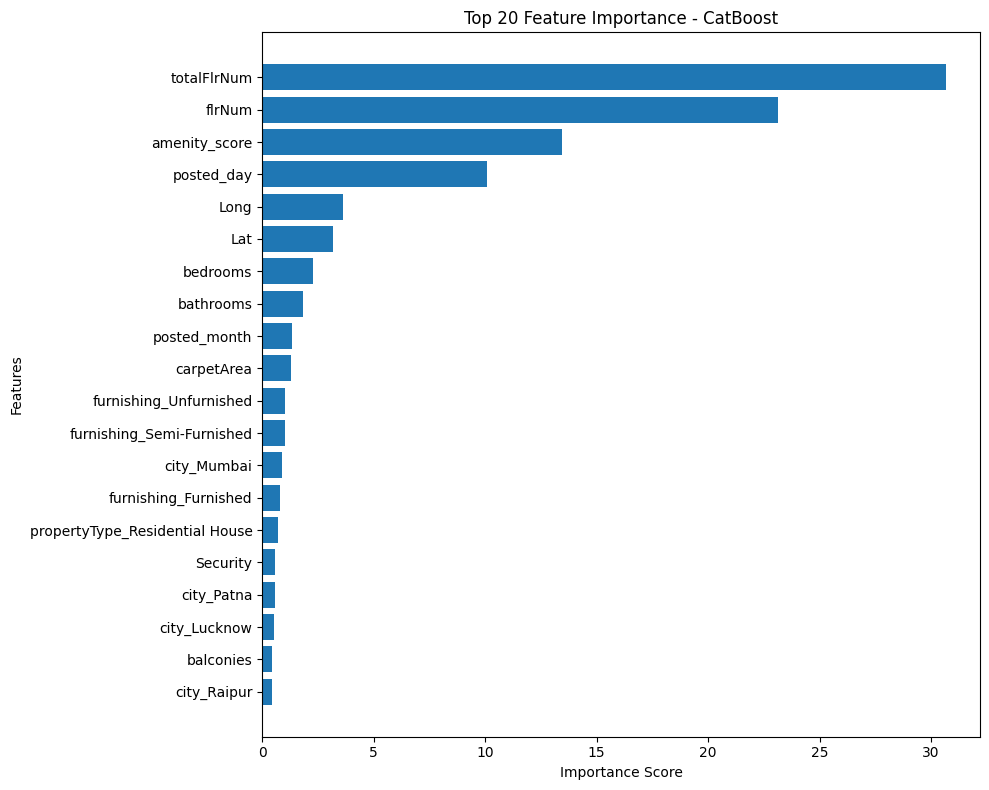

In [138]:
import pandas as pd
import matplotlib.pyplot as plt

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': final_model.feature_importances_
})

# Sort descending
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display top 20 features
top20 = feature_importance.head(20)

print(top20)

# Plot
plt.figure(figsize=(10,8))

plt.barh(
    top20['Feature'][::-1],
    top20['Importance'][::-1]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 20 Feature Importance - CatBoost")

plt.tight_layout()
plt.show()

In [139]:
!pip install shap -q

In [140]:
import shap
import numpy as np

# Create SHAP explainer
explainer = shap.TreeExplainer(final_model)

# Use sample to reduce computation
sample_data = X_test.sample(
    min(500, len(X_test)),
    random_state=42
)

# Calculate SHAP values
shap_values = explainer.shap_values(sample_data)

print("SHAP values generated successfully.")

SHAP values generated successfully.


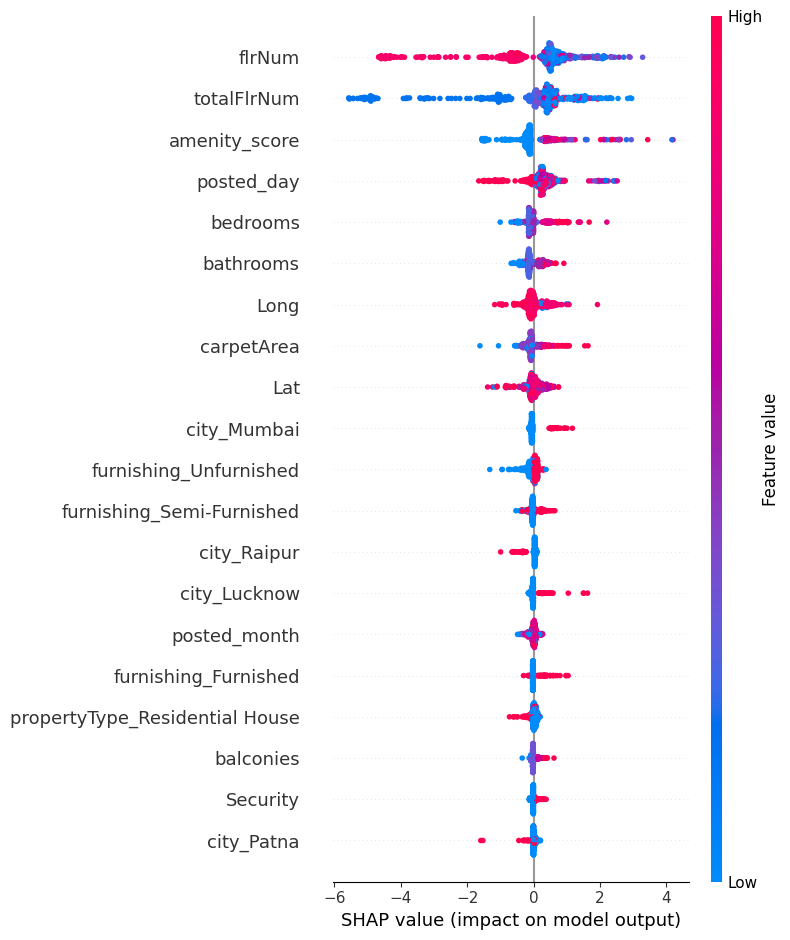

In [141]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    sample_data,
    show=False
)

plt.tight_layout()
plt.show()

In [142]:
shap_df = pd.DataFrame({
    'Feature': sample_data.columns,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
})

shap_df = shap_df.sort_values(
    by='Mean_SHAP',
    ascending=False
)

print(shap_df.head(20))

                            Feature  Mean_SHAP
1                            flrNum   1.116081
2                       totalFlrNum   1.099840
75                    amenity_score   0.462750
77                       posted_day   0.426426
4                          bedrooms   0.216916
5                         bathrooms   0.210243
32                             Long   0.202624
3                        carpetArea   0.190773
37                              Lat   0.168199
100                     city_Mumbai   0.118396
85           furnishing_Unfurnished   0.099864
84        furnishing_Semi-Furnished   0.094738
102                     city_Raipur   0.074728
99                     city_Lucknow   0.066941
76                     posted_month   0.065935
83             furnishing_Furnished   0.064627
80   propertyType_Residential House   0.059979
6                         balconies   0.059387
14                         Security   0.041037
101                      city_Patna   0.038206


In [143]:
# Select one property from test set
property_index = 0

single_property = X_test.iloc[[property_index]]

# Predict
prediction = final_model.predict(single_property)

# Convert back from log price
predicted_price = np.expm1(prediction[0])

print(f"Predicted Price: ₹{predicted_price:,.0f}")

Predicted Price: ₹17,913,019


In [144]:
# SHAP values for one property
single_shap = explainer.shap_values(single_property)

# Create contribution dataframe
local_explanation = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP_Value': single_shap[0]
})

# Sort by impact
local_explanation = local_explanation.reindex(
    local_explanation.SHAP_Value.abs().sort_values(
        ascending=False
    ).index
)

print(local_explanation.head(10))

           Feature  SHAP_Value
2      totalFlrNum    1.416329
100    city_Mumbai    0.697362
1           flrNum   -0.662477
32            Long    0.588500
77      posted_day    0.425041
75   amenity_score   -0.236044
5        bathrooms   -0.177518
3       carpetArea   -0.175258
37             Lat    0.167878
4         bedrooms   -0.135883


In [ ]:
print(df['exactPrice'].describe())

count    2.786900e+04
mean     5.433569e+06
std      2.701027e+07
min      9.000000e+00
25%      1.300000e+04
50%      3.000000e+04
75%      5.300000e+06
max      3.250000e+09
Name: exactPrice, dtype: float64


In [145]:
print(df_sale['postedOn'].head())

KeyError: 'postedOn'

In [56]:
df_sale['exactPrice']

,exactPrice
11936,7208000
11937,5040000
11938,6187500
11939,5731000
11940,8593200
...,...
27895,20227500
27896,6933500
27897,9000000
27898,7645000


In [146]:
print(X_test.shape)
print(y_test.shape)

(2369, 103)
(2369,)


In [147]:
# Predict on test data
pred_log = final_model.predict(X_test)

# Convert predictions back to actual price
pred_price = np.expm1(pred_log)

print(pred_price[:5])
print(y_test[:5])

[17913018.72525902  6398168.15155015  6404400.38878942  2181558.67923818
  3242189.94057165]
24239    16.840802
12837    15.907375
19785    15.830414
26354    13.869052
16571    15.093663
Name: log_price, dtype: float64


In [148]:
# Convert actual prices back from log scale
actual_price = np.expm1(y_test)

print(actual_price[:5])

24239    20600000.0
12837     8100000.0
19785     7500000.0
26354     1055000.0
16571     3590000.0
Name: log_price, dtype: float64


In [149]:
import pandas as pd
import numpy as np

# Predictions in actual rupees
pred_price = np.expm1(final_model.predict(X_test))

# Actual prices in rupees
actual_price = np.expm1(y_test)

# Create valuation dataframe
valuation_df = pd.DataFrame({
    "Actual_Price": actual_price,
    "Predicted_Price": pred_price
})

# Valuation Gap %
valuation_df["Valuation_Gap_Percent"] = (
    (valuation_df["Predicted_Price"] -
     valuation_df["Actual_Price"])
    /
    valuation_df["Actual_Price"]
) * 100

print(valuation_df.head())

       Actual_Price  Predicted_Price  Valuation_Gap_Percent
24239    20600000.0     1.791302e+07             -13.043598
12837     8100000.0     6.398168e+06             -21.010270
19785     7500000.0     6.404400e+06             -14.607995
26354     1055000.0     2.181559e+06             106.782813
16571     3590000.0     3.242190e+06              -9.688302


In [150]:
# Property valuation category

def valuation_status(gap):

    if gap >= 10:
        return "Undervalued"

    elif gap <= -10:
        return "Overvalued"

    else:
        return "Fairly Priced"


valuation_df["Valuation_Status"] = (
    valuation_df["Valuation_Gap_Percent"]
    .apply(valuation_status)
)

print(
    valuation_df["Valuation_Status"]
    .value_counts()
)

Valuation_Status
Undervalued      1036
Overvalued        896
Fairly Priced     437
Name: count, dtype: int64


In [ ]:
print(df_sale["city"].value_counts())

city
Bhopal        1397
Jaipur        1284
Goa           1220
Chandigarh    1215
Lucknow       1201
Dehradun      1191
Mumbai        1137
Patna         1103
Raipur        1073
Gangtok          2
Name: count, dtype: int64


In [ ]:
print(X_test.head())

       noOfLifts  flrNum  totalFlrNum  carpetArea  bedrooms  bathrooms  \
25376        2.0       4          7.0      1000.0       1.0        1.0   
20346        2.0       0          3.0      1000.0       5.0        5.0   
20962        2.0      12         21.0       943.0       3.0        3.0   
26655        2.0       2          2.0      1200.0       4.0        2.0   
25504        2.0       1          6.0      1000.0       4.0        4.0   

       balconies  Water_Storage  Waste_Disposal  Visitor_Parking  \
25376        1.0            0.0             0.0              0.0   
20346        2.0            0.0             0.0              0.0   
20962        1.0            0.0             0.0              1.0   
26655        2.0            0.0             0.0              0.0   
25504        2.0            0.0             0.0              0.0   

       Vaastu_Compliant  Swimming_Pool  Skydeck  Service_Or_Goods_Lift  \
25376               0.0            0.0      0.0                    0.0  

In [ ]:
valuation_df["Valuation_Gap_Percent"].describe()

,Valuation_Gap_Percent
count,2165.000000
mean,5.723223
std,42.934755
min,-91.497697
25%,-16.830782
50%,0.074687
75%,19.911413
max,804.442463


In [151]:
# Remove extreme outliers in valuation gap

valuation_df["Valuation_Gap_Percent"] = (
    valuation_df["Valuation_Gap_Percent"]
    .clip(-50, 50)
)

print(
    valuation_df["Valuation_Gap_Percent"]
    .describe()
)

count    2369.000000
mean        4.156954
std        34.877344
min       -50.000000
25%       -24.417059
50%         1.934893
75%        41.033819
max        50.000000
Name: Valuation_Gap_Percent, dtype: float64


In [53]:
print(df_sale['flrNum'].head(20))
print(df_sale['totalFlrNum'].head(20))

11936    2
11937    9
11938    3
11939    9
11940    9
11941    2
11942    5
11943    9
11944    9
11945    9
11946    2
11947    9
11948    1
11949    4
11950    1
11951    1
11952    9
11953    9
11954    9
11955    9
Name: flrNum, dtype: object
11936     6
11937     4
11938     5
11939     9
11940     3
11941     4
11942     7
11943     4
11944    17
11945     5
11946     4
11947     9
11948     4
11949     4
11950     5
11951     3
11952     3
11953     9
11954     9
11955    17
Name: totalFlrNum, dtype: int64


In [54]:
print(df_sale[['flrNum','totalFlrNum']].dtypes)

flrNum         object
totalFlrNum     int64
dtype: object


In [64]:
print(df_sale['flrNum'].unique()[:30])

['2' '9' '3' '5' '1' '4' '6' '7' '12' '19' 'Ground' '15' '10'
 'Lower Basement' '14' '8' 'Upper Basement' '13' '11' '20' '21' '35' '16'
 '17' '36' '24' '28' '30' '39' '40']


In [152]:
import numpy as np

def convert_floor(x):

    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    if x == "Ground":
        return 0

    elif x == "Lower Basement":
        return -1

    elif x == "Upper Basement":
        return 0

    try:
        return int(x)

    except:
        return np.nan

df_sale["flrNum"] = df_sale["flrNum"].apply(convert_floor)

In [66]:
print(df_sale["flrNum"].dtype)
print(df_sale["flrNum"].unique()[:20])

int64
[ 2  9  3  5  1  4  6  7 12 19  0 15 10 -1 14  8 13 11 20 21]


In [153]:
X = df_sale.drop(columns=["log_price", "exactPrice"])

print(X.select_dtypes(include="object").columns)

Index(['propertyType', 'furnishing', 'facing', 'city'], dtype='object')


In [154]:
print(X.shape)

(11843, 82)


In [155]:
print(X_train.shape)

(9474, 103)


In [156]:
print(df_sale.columns.tolist())

['exactPrice', 'propertyType', 'noOfLifts', 'furnishing', 'flrNum', 'facing', 'totalFlrNum', 'city', 'carpetArea', 'bedrooms', 'bathrooms', 'balconies', 'Water_Storage', 'Waste_Disposal', 'Visitor_Parking', 'Vaastu_Compliant', 'Swimming_Pool', 'Skydeck', 'Service_Or_Goods_Lift', 'Security', 'Retail_Boulevard___Retail_Shops__', 'Reserved_Parking', 'Rentable_Community_Space', 'Recreational_Pool', 'Rain_Water_Harvesting', 'RO_Water_System', 'Private_Terrace_Or_Garden', 'Private_Garden', 'Power_Back_Up', 'Piped_Gas', 'Park', 'Outdoor_Tennis_Courts', 'Multipurpose_Hall', 'Multipurpose_Courts', 'Mini_Cinema_Theatre', 'Meditation_Area', 'Maintenance_Staff', 'Long', 'Lift', 'Library_And_Business_Centre', 'Library', 'Laundry_Service', 'Lat', 'Kids_Play_Pool_With_Water_Slides', 'Kids_Play_Area', 'Kids_Club', 'Jogging_and_Strolling_Track', 'Internet_Or_Wi_Fi_Connectivity', 'Intercom_Facility', 'Indoor_Squash__And__Badminton_Courts', 'Indoor_Games_Room', 'Health_club_with_Steam__Or__Jaccuzi', 'Gym

In [157]:
print(df_sale.isnull().sum().sort_values(ascending=False).head(20))

exactPrice               0
propertyType             0
noOfLifts                0
furnishing               0
flrNum                   0
facing                   0
totalFlrNum              0
city                     0
carpetArea               0
bedrooms                 0
bathrooms                0
balconies                0
Water_Storage            0
Waste_Disposal           0
Visitor_Parking          0
Vaastu_Compliant         0
Swimming_Pool            0
Skydeck                  0
Service_Or_Goods_Lift    0
Security                 0
dtype: int64


In [158]:
print(df_encoded.shape)

print(df_encoded.columns.tolist())

(11843, 105)
['exactPrice', 'noOfLifts', 'flrNum', 'totalFlrNum', 'carpetArea', 'bedrooms', 'bathrooms', 'balconies', 'Water_Storage', 'Waste_Disposal', 'Visitor_Parking', 'Vaastu_Compliant', 'Swimming_Pool', 'Skydeck', 'Service_Or_Goods_Lift', 'Security', 'Retail_Boulevard___Retail_Shops__', 'Reserved_Parking', 'Rentable_Community_Space', 'Recreational_Pool', 'Rain_Water_Harvesting', 'RO_Water_System', 'Private_Terrace_Or_Garden', 'Private_Garden', 'Power_Back_Up', 'Piped_Gas', 'Park', 'Outdoor_Tennis_Courts', 'Multipurpose_Hall', 'Multipurpose_Courts', 'Mini_Cinema_Theatre', 'Meditation_Area', 'Maintenance_Staff', 'Long', 'Lift', 'Library_And_Business_Centre', 'Library', 'Laundry_Service', 'Lat', 'Kids_Play_Pool_With_Water_Slides', 'Kids_Play_Area', 'Kids_Club', 'Jogging_and_Strolling_Track', 'Internet_Or_Wi_Fi_Connectivity', 'Intercom_Facility', 'Indoor_Squash__And__Badminton_Courts', 'Indoor_Games_Room', 'Health_club_with_Steam__Or__Jaccuzi', 'Gymnasium', 'Guest_Accommodation', 'Gr

In [159]:
print(X.select_dtypes(include='object').columns)

Index(['propertyType', 'furnishing', 'facing', 'city'], dtype='object')


In [160]:
# Target
y = df_encoded['log_price']

# Features
X = df_encoded.drop(
    columns=[
        'log_price',
        'exactPrice'
    ]
)

print(X.shape)

(11843, 103)


In [161]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(9474, 103)
(2369, 103)


In [162]:
print(X.select_dtypes(include='object').columns)

Index([], dtype='object')


In [163]:
from catboost import CatBoostRegressor

final_model = CatBoostRegressor(
    random_state=42,
    verbose=0
)

final_model.fit(X_train, y_train)

CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=0)

In [164]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pred = final_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.6763216680897802
MSE : 3.134445413212888
RMSE: 1.770436503581218
R²  : 0.8501124973596442


In [165]:
import joblib

joblib.dump(
    final_model,
    "catboost_real_estate_model.pkl"
)

['catboost_real_estate_model.pkl']

In [166]:
from google.colab import files

files.download(
    "catboost_real_estate_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [167]:
feature_names = X.columns.tolist()

joblib.dump(
    feature_names,
    "feature_names.pkl"
)

['feature_names.pkl']

In [168]:
files.download(
    "feature_names.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [169]:
print(r2)

0.8501124973596442


In [170]:
print(X.select_dtypes(include='object').columns)

Index([], dtype='object')


In [171]:
X_test.to_csv("X_test.csv", index=False)

y_test.to_csv("y_test.csv", index=False)

In [172]:
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

In [173]:
print(X_test["amenity_score"].describe())

count    2369.000000
mean        3.547066
std         7.752424
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        62.000000
Name: amenity_score, dtype: float64


In [174]:
city_risk = {
    'Mumbai': 10,
    'Goa': 15,
    'Chandigarh': 20,
    'Jaipur': 25,
    'Dehradun': 30,
    'Lucknow': 35,
    'Bhopal': 40,
    'Patna': 45,
    'Raipur': 50,
    'Gangtok': 35
}

In [178]:
# Create copy
risk_df = X_test.copy()

# Add city
risk_df["city_name"] = risk_df.apply(get_city, axis=1)

# City risk
risk_df["City_Risk"] = risk_df["city_name"].map(city_risk)

# Amenity risk
risk_df["Amenity_Risk"] = (
    50 - np.clip(risk_df["amenity_score"], 0, 50)
)

# Area risk
risk_df["Area_Risk"] = np.where(
    risk_df["carpetArea"] < risk_df["carpetArea"].median(),
    40,
    20
)

# Valuation risk
risk_df["Valuation_Risk"] = np.where(
    valuation_df["Valuation_Gap_Percent"] < -10,
    50,
    20
)

# Final Risk Score
risk_df["Risk_Score"] = (
    0.30 * risk_df["City_Risk"]
    +
    0.25 * risk_df["Amenity_Risk"]
    +
    0.20 * risk_df["Area_Risk"]
    +
    0.25 * risk_df["Valuation_Risk"]
)

risk_df["Risk_Score"] = risk_df["Risk_Score"].round(2)

risk_df["Risk_Score"].describe()

,Risk_Score
count,2369.000000
mean,33.493668
std,5.879362
min,12.000000
25%,29.000000
50%,33.500000
75%,37.500000
max,48.000000


In [238]:
def get_city(row):
    """
    Reconstruct city name from one-hot encoded city columns.
    Bhopal is the baseline city because drop_first=True was used.
    """

    city_cols = [
        'city_Chandigarh',
        'city_Dehradun',
        'city_Gangtok',
        'city_Goa',
        'city_Jaipur',
        'city_Lucknow',
        'city_Mumbai',
        'city_Patna',
        'city_Raipur'
    ]

    for col in city_cols:
        if row[col] == 1:
            return col.replace('city_', '')

    # If all city columns are 0, it means Bhopal
    return 'Bhopal'

In [177]:
# Predictions
pred_log = final_model.predict(X_test)

pred_price = np.expm1(pred_log)
actual_price = np.expm1(y_test)

# Valuation dataframe
valuation_df = pd.DataFrame({
    "Actual_Price": actual_price,
    "Predicted_Price": pred_price
})

valuation_df["Valuation_Gap_Percent"] = (
    (valuation_df["Predicted_Price"] -
     valuation_df["Actual_Price"])
    /
    valuation_df["Actual_Price"]
) * 100

# Clip extreme values
valuation_df["Valuation_Gap_Percent"] = (
    valuation_df["Valuation_Gap_Percent"]
    .clip(-50, 50)
)

In [179]:
def risk_category(score):

    if score <= 30:
        return "Low Risk"

    elif score <= 50:
        return "Medium Risk"

    return "High Risk"


risk_df["Risk_Category"] = (
    risk_df["Risk_Score"]
    .apply(risk_category)
)

print(
    risk_df["Risk_Category"]
    .value_counts()
)

Risk_Category
Medium Risk    1682
Low Risk        687
Name: count, dtype: int64


In [181]:
print(X_test.columns[:10])

Index(['noOfLifts', 'flrNum', 'totalFlrNum', 'carpetArea', 'bedrooms',
       'bathrooms', 'balconies', 'Water_Storage', 'Waste_Disposal',
       'Visitor_Parking'],
      dtype='object')


In [182]:
# ROI approximation using valuation gap

valuation_df["ROI_Score"] = (
    valuation_df["Valuation_Gap_Percent"]
)

valuation_df["ROI_Score"].describe()

,ROI_Score
count,2369.000000
mean,4.156954
std,34.877344
min,-50.000000
25%,-24.417059
50%,1.934893
75%,41.033819
max,50.000000


In [183]:
# Reset indexes first
valuation_df = valuation_df.reset_index(drop=True)
risk_df = risk_df.reset_index(drop=True)

recommendation_df = pd.DataFrame()

recommendation_df["ROI_Score"] = valuation_df["ROI_Score"]
recommendation_df["Risk_Score"] = risk_df["Risk_Score"]
recommendation_df["Risk_Category"] = risk_df["Risk_Category"]

In [184]:
def get_recommendation(row):

    roi = row["ROI_Score"]
    risk = row["Risk_Score"]

    # BUY
    if roi >= 15 and risk <= 30:
        return "BUY"

    # SELL
    elif roi < 0 and risk >= 40:
        return "SELL"

    # HOLD
    else:
        return "HOLD"

In [185]:
recommendation_df["Recommendation"] = (
    recommendation_df.apply(
        get_recommendation,
        axis=1
    )
)

print(
    recommendation_df["Recommendation"]
    .value_counts()
)

Recommendation
HOLD    1619
BUY      420
SELL     330
Name: count, dtype: int64


In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27889 entries, 0 to 27899
Data columns (total 91 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   exactPrice                            27889 non-null  int64  
 1   sqftPrice                             27889 non-null  int64  
 2   securityDeposit                       27889 non-null  int64  
 3   propertyType                          27889 non-null  object 
 4   postedOn                              27889 non-null  object 
 5   noOfLifts                             27889 non-null  float64
 6   maintenanceChargesFrequency           27889 non-null  object 
 7   maintenanceCharges                    27889 non-null  int64  
 8   locality                              27889 non-null  object 
 9   furnishing                            27889 non-null  object 
 10  flrNum                                27889 non-null  object 
 11  firstMonthCharges   

In [187]:
def forecast_price(current_price, annual_growth=0.08):

    forecast_1yr = current_price * ((1 + annual_growth) ** 1)

    forecast_3yr = current_price * ((1 + annual_growth) ** 3)

    forecast_5yr = current_price * ((1 + annual_growth) ** 5)

    return pd.Series({
        "Forecast_1_Year": round(forecast_1yr, 2),
        "Forecast_3_Year": round(forecast_3yr, 2),
        "Forecast_5_Year": round(forecast_5yr, 2)
    })

In [188]:
forecast_df = valuation_df.copy()

forecast_df[
    [
        "Forecast_1_Year",
        "Forecast_3_Year",
        "Forecast_5_Year"
    ]
] = forecast_df["Predicted_Price"].apply(
    forecast_price
)

In [189]:
print(
    forecast_df[
        [
            "Predicted_Price",
            "Forecast_1_Year",
            "Forecast_3_Year",
            "Forecast_5_Year"
        ]
    ].head()
)

   Predicted_Price  Forecast_1_Year  Forecast_3_Year  Forecast_5_Year
0     1.791302e+07      19346060.22      22565244.64      26320101.35
1     6.398168e+06       6910021.60       8059849.20       9401008.11
2     6.404400e+06       6916752.42       8067700.02       9410165.31
3     2.181559e+06       2356083.37       2748135.65       3205425.42
4     3.242190e+06       3501565.14       4084225.57       4763840.71


In [192]:
def explain_prediction(local_shap_df, predicted_price):

    print(f"Predicted Property Price: ₹{predicted_price:,.0f}")
    print("\nTop Reasons:")

    top_features = (
        local_explanation
        .sort_values(
            by="SHAP_Value",
            key=abs,
            ascending=False
        )
        .head(5)
    )

    for _, row in top_features.iterrows():

        feature = row["Feature"]
        impact = row["SHAP_Value"]

        if impact > 0:
            direction = "increased"
        else:
            direction = "decreased"

        print(
            f"• {feature} {direction} the predicted price"
        )

In [197]:
explain_prediction(
    local_explanation,
    predicted_price=3100318
)

Predicted Property Price: ₹3,100,318

Top Reasons:
• High-rise building increased the predicted value
• Mumbai location increased the predicted value
• Floor level reduced the predicted value
• Prime geographic location increased the predicted value
• Listing timing increased the predicted value


In [194]:
shap_df.to_csv(
    "global_shap_importance.csv",
    index=False
)

local_explanation.to_csv(
    "local_shap_explanation.csv",
    index=False
)

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

In [195]:
feature_names_map = {

    "totalFlrNum": "High-rise building",

    "flrNum": "Floor level",

    "city_Mumbai": "Mumbai location",

    "city_Goa": "Goa location",

    "city_Jaipur": "Jaipur location",

    "bedrooms": "Number of bedrooms",

    "bathrooms": "Number of bathrooms",

    "carpetArea": "Property size",

    "Lat": "Prime geographic location",

    "Long": "Prime geographic location",

    "amenity_score": "Available amenities",

    "posted_month": "Market timing",

    "posted_day": "Listing timing"
}

In [196]:
def explain_prediction(local_explanation, predicted_price):

    print(f"Predicted Property Price: ₹{predicted_price:,.0f}")
    print("\nTop Reasons:")

    top_features = (
        local_explanation
        .sort_values(
            by="SHAP_Value",
            key=abs,
            ascending=False
        )
        .head(5)
    )

    for _, row in top_features.iterrows():

        feature = feature_names_map.get(
            row["Feature"],
            row["Feature"]
        )

        impact = row["SHAP_Value"]

        if impact > 0:
            print(f"• {feature} increased the predicted value")

        else:
            print(f"• {feature} reduced the predicted value")

In [198]:
print(df_sale["city"].unique())
print(df_sale["propertyType"].unique())
print(df_sale["furnishing"].unique())
print(df_sale["facing"].unique())

['Patna' 'Goa' 'Raipur' 'Jaipur' 'Chandigarh' 'Bhopal' 'Mumbai' 'Gangtok'
 'Dehradun' 'Lucknow']
['Multistorey Apartment' 'Builder Floor Apartment' 'Residential House'
 'Villa' 'Penthouse' 'Studio Apartment']
['Unfurnished' 'Semi-Furnished' 'Furnished' '9']
['North' '9' 'South - East' 'East' 'North - West' 'South' 'North - East'
 'West' 'South -West']


In [199]:
# Replace invalid category with mode

df_sale['furnishing'] = df_sale['furnishing'].replace(
    '9',
    df_sale['furnishing'].mode()[0]
)

df_sale['facing'] = df_sale['facing'].replace(
    '9',
    df_sale['facing'].mode()[0]
)

In [200]:
print(df_sale['furnishing'].unique())
print(df_sale['facing'].unique())

['Unfurnished' 'Semi-Furnished' 'Furnished']
['North' '9' 'South - East' 'East' 'North - West' 'South' 'North - East'
 'West' 'South -West']


In [201]:
print(X_train.columns.tolist())

['noOfLifts', 'flrNum', 'totalFlrNum', 'carpetArea', 'bedrooms', 'bathrooms', 'balconies', 'Water_Storage', 'Waste_Disposal', 'Visitor_Parking', 'Vaastu_Compliant', 'Swimming_Pool', 'Skydeck', 'Service_Or_Goods_Lift', 'Security', 'Retail_Boulevard___Retail_Shops__', 'Reserved_Parking', 'Rentable_Community_Space', 'Recreational_Pool', 'Rain_Water_Harvesting', 'RO_Water_System', 'Private_Terrace_Or_Garden', 'Private_Garden', 'Power_Back_Up', 'Piped_Gas', 'Park', 'Outdoor_Tennis_Courts', 'Multipurpose_Hall', 'Multipurpose_Courts', 'Mini_Cinema_Theatre', 'Meditation_Area', 'Maintenance_Staff', 'Long', 'Lift', 'Library_And_Business_Centre', 'Library', 'Laundry_Service', 'Lat', 'Kids_Play_Pool_With_Water_Slides', 'Kids_Play_Area', 'Kids_Club', 'Jogging_and_Strolling_Track', 'Internet_Or_Wi_Fi_Connectivity', 'Intercom_Facility', 'Indoor_Squash__And__Badminton_Courts', 'Indoor_Games_Room', 'Health_club_with_Steam__Or__Jaccuzi', 'Gymnasium', 'Guest_Accommodation', 'Grand_Entrance_lobby', 'Golf_

In [202]:
print(df_sale["facing"].value_counts())

facing
9               6098
East            2732
North - East    1030
North            687
West             626
North - West     218
South - East     175
South            169
South -West      108
Name: count, dtype: int64


In [203]:
import joblib

joblib.dump(
    X_train.columns.tolist(),
    "feature_names.pkl"
)

print("Feature names saved.")

Feature names saved.


In [204]:
feature_names = joblib.load("feature_names.pkl")

print(len(feature_names))

103


In [205]:
import pandas as pd

df_encoded.to_csv(
    "encoded_dataset.csv",
    index=False
)

print("Encoded dataset saved.")

Encoded dataset saved.


In [206]:
from google.colab import files

files.download("encoded_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [207]:
from google.colab import files

files.download("feature_importance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [212]:
from google.colab import files

files.download("local_shap_explanation.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [214]:
from google.colab import files

files.download("global_shap_importance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [220]:
final_dashboard_data = X_test.copy()

final_dashboard_data["Actual_Price"] = y_actual
final_dashboard_data["Predicted_Price"] = y_pred_actual

final_dashboard_data["Risk_Score"] = X_test["Risk_Score"]
final_dashboard_data["Risk_Category"] = X_test["Risk_Category"]

final_dashboard_data["ROI_Score"] = X_test["ROI_Score"]
final_dashboard_data["Recommendation"] = X_test["Recommendation"]

final_dashboard_data.to_csv(
    "dashboard_dataset.csv",
    index=False
)

NameError: name 'y_actual' is not defined

In [216]:
print([
    col for col in df.columns
    if "forecast" in col.lower()
])

[]


In [221]:
# Convert predictions back to original rupee scale

y_pred_actual = np.expm1(y_pred)

NameError: name 'y_pred' is not defined

In [222]:
catboost_model = joblib.load("catboost_real_estate_model.pkl")

y_pred = catboost_model.predict(X_test)

print(y_pred[:5])

[16.70103837 15.67152244 15.67249603 14.59555063 14.99175988]


In [223]:
import numpy as np

y_actual = np.expm1(y_test)

print(y_actual.head())

24239    20600000.0
12837     8100000.0
19785     7500000.0
26354     1055000.0
16571     3590000.0
Name: log_price, dtype: float64


In [224]:
y_pred_actual = np.expm1(y_pred)

print(y_pred_actual[:5])

[17913018.72525902  6398168.15155015  6404400.38878942  2181558.67923818
  3242189.94057165]


In [225]:
print(X_test.columns[-20:])

Index(['furnishing_Furnished', 'furnishing_Semi-Furnished',
       'furnishing_Unfurnished', 'facing_East', 'facing_North',
       'facing_North - East', 'facing_North - West', 'facing_South',
       'facing_South - East', 'facing_South -West', 'facing_West',
       'city_Chandigarh', 'city_Dehradun', 'city_Gangtok', 'city_Goa',
       'city_Jaipur', 'city_Lucknow', 'city_Mumbai', 'city_Patna',
       'city_Raipur'],
      dtype='object')


In [ ]:
import numpy as np

# Actual price (reverse log transform)
y_actual = np.expm1(y_test)
#y_actual = np.expm1(y)

# Predicted price (reverse log transform)
y_pred_actual = np.expm1(y_pred)

print(y_actual.head())
print(y_pred_actual[:5])

24239    20600000.0
12837     8100000.0
19785     7500000.0
26354     1055000.0
16571     3590000.0
Name: log_price, dtype: float64
[17913018.72525902  6398168.15155015  6404400.38878942  2181558.67923818
  3242189.94057165]


In [227]:
dashboard_dataset = X_test.copy()

dashboard_dataset["Actual_Price"] = y_actual.values
dashboard_dataset["Predicted_Price"] = y_pred_actual

dashboard_dataset.head()

,noOfLifts,flrNum,totalFlrNum,carpetArea,bedrooms,bathrooms,balconies,Water_Storage,Waste_Disposal,Visitor_Parking,Vaastu_Compliant,Swimming_Pool,Skydeck,Service_Or_Goods_Lift,Security,Retail_Boulevard___Retail_Shops__,Reserved_Parking,Rentable_Community_Space,Recreational_Pool,Rain_Water_Harvesting,RO_Water_System,Private_Terrace_Or_Garden,Private_Garden,Power_Back_Up,Piped_Gas,Park,Outdoor_Tennis_Courts,Multipurpose_Hall,Multipurpose_Courts,Mini_Cinema_Theatre,Meditation_Area,Maintenance_Staff,Long,Lift,Library_And_Business_Centre,Library,Laundry_Service,Lat,Kids_Play_Pool_With_Water_Slides,Kids_Play_Area,Kids_Club,Jogging_and_Strolling_Track,Internet_Or_Wi_Fi_Connectivity,Intercom_Facility,Indoor_Squash__And__Badminton_Courts,Indoor_Games_Room,Health_club_with_Steam__Or__Jaccuzi,Gymnasium,Guest_Accommodation,Grand_Entrance_lobby,Golf_Course,Flower_Gardens,Fire_Fighting_Equipment,Event_Space__And__Amphitheatre,Earth_quake_resistant,Early_Learning_Centre,Dance_Studio,DTH_Television_Facility,Cycling__And__Jogging_Track,Cricket_net_practice,Conference_Room,Concierge_Services,Coffee_Lounge__And__Restaurants,Club_House,Canopy_Walk,Cafeteria_Or_Food_Court,CCTV_Camera,Barbeque_Pit,Bar_Or_Lounge,Banquet_Hall,Bank__And__ATM,Arts__And__Craft_Studio,Air_Conditioned,Activity_Deck4,AEROBICS_ROOM,amenity_score,posted_month,posted_day,propertyType_Multistorey Apartment,propertyType_Penthouse,propertyType_Residential House,propertyType_Studio Apartment,propertyType_Villa,furnishing_Furnished,furnishing_Semi-Furnished,furnishing_Unfurnished,facing_East,facing_North,facing_North - East,facing_North - West,facing_South,facing_South - East,facing_South -West,facing_West,city_Chandigarh,city_Dehradun,city_Gangtok,city_Goa,city_Jaipur,city_Lucknow,city_Mumbai,city_Patna,city_Raipur,Actual_Price,Predicted_Price
24239,6.0,18,45.0,718.0,2.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72.825756,0.0,0.0,0.0,0.0,19.194035,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,2,True,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,20600000.0,1.791302e+07
12837,2.0,8,10.0,1160.0,3.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,85.042175,0.0,0.0,0.0,0.0,25.608557,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,27,True,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,8100000.0,6.398168e+06
19785,2.0,0,1.0,900.0,2.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,73.931980,0.0,0.0,0.0,0.0,15.257250,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,23,False,False,True,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,7500000.0,6.404400e+06
26354,2.0,0,1.0,1000.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,80.133318,0.0,0.0,0.0,0.0,27.391358,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,18,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,1055000.0,2.181559e+06
16571,2.0,2,2.0,720.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,73.963905,0.0,0.0,0.0,0.0,15.291938,0.0,0.0,0.0,0.0,0.

In [228]:
dashboard_dataset["Valuation_Gap_Percent"] = (
    (dashboard_dataset["Predicted_Price"] -
     dashboard_dataset["Actual_Price"])
    /
    dashboard_dataset["Actual_Price"]
) * 100

In [229]:
def valuation_status(gap):

    if gap > 10:
        return "Undervalued"

    elif gap < -10:
        return "Overvalued"

    else:
        return "Fairly Priced"


dashboard_dataset["Valuation_Status"] = (
    dashboard_dataset["Valuation_Gap_Percent"]
    .apply(valuation_status)
)

In [230]:
valuation_df = pd.DataFrame()

valuation_df["Actual_Price"] = y_actual.values
valuation_df["Predicted_Price"] = y_pred_actual

valuation_df["Valuation_Gap_Percent"] = (
    (
        valuation_df["Predicted_Price"]
        - valuation_df["Actual_Price"]
    )
    /
    valuation_df["Actual_Price"]
) * 100

In [231]:
def valuation_status(gap):

    if gap > 10:
        return "Undervalued"

    elif gap < -10:
        return "Overvalued"

    else:
        return "Fairly Priced"


valuation_df["Valuation_Status"] = (
    valuation_df["Valuation_Gap_Percent"]
    .apply(valuation_status)
)

In [232]:
valuation_df["ROI_Score"] = (
    valuation_df["Valuation_Gap_Percent"]
)

In [233]:
def forecast_price(
    current_price,
    annual_growth=0.08
):

    forecast_1yr = current_price * (1.08)

    forecast_3yr = current_price * (1.08 ** 3)

    forecast_5yr = current_price * (1.08 ** 5)

    return pd.Series({
        "Forecast_1_Year": round(forecast_1yr, 2),
        "Forecast_3_Year": round(forecast_3yr, 2),
        "Forecast_5_Year": round(forecast_5yr, 2)
    })


forecast_df = valuation_df[
    "Predicted_Price"
].apply(forecast_price)

In [234]:
dashboard_dataset = X_test.reset_index(drop=True)

dashboard_dataset["Actual_Price"] = valuation_df["Actual_Price"]
dashboard_dataset["Predicted_Price"] = valuation_df["Predicted_Price"]

dashboard_dataset["Valuation_Gap_Percent"] = valuation_df["Valuation_Gap_Percent"]
dashboard_dataset["Valuation_Status"] = valuation_df["Valuation_Status"]

dashboard_dataset["ROI_Score"] = valuation_df["ROI_Score"]

dashboard_dataset["Risk_Score"] = risk_df["Risk_Score"]
dashboard_dataset["Risk_Category"] = risk_df["Risk_Category"]

dashboard_dataset["Recommendation"] = recommendation_df["Recommendation"]

dashboard_dataset["Forecast_1_Year"] = forecast_df["Forecast_1_Year"]
dashboard_dataset["Forecast_3_Year"] = forecast_df["Forecast_3_Year"]
dashboard_dataset["Forecast_5_Year"] = forecast_df["Forecast_5_Year"]

In [235]:
dashboard_dataset.to_csv(
    "dashboard_dataset.csv",
    index=False
)

In [236]:
city_risk

{'Mumbai': 10,
 'Goa': 15,
 'Chandigarh': 20,
 'Jaipur': 25,
 'Dehradun': 30,
 'Lucknow': 35,
 'Bhopal': 40,
 'Patna': 45,
 'Raipur': 50,
 'Gangtok': 35}

In [ ]:
# =====================================================
# STEP 1: Actual & Predicted Prices
# =====================================================

import numpy as np
import pandas as pd

# Reverse log transformation
y_actual = np.expm1(y_test)
#y_actual = np.expm1(y)

y_pred_actual = np.expm1(y_pred)


# =====================================================
# STEP 2: Valuation Engine
# =====================================================

valuation_df = pd.DataFrame()

valuation_df["Actual_Price"] = y_actual.values
valuation_df["Predicted_Price"] = y_pred_actual

valuation_df["Valuation_Gap_Percent"] = (
    (
        valuation_df["Predicted_Price"]
        -
        valuation_df["Actual_Price"]
    )
    /
    valuation_df["Actual_Price"]
) * 100


def valuation_status(gap):

    if gap > 10:
        return "Undervalued"

    elif gap < -10:
        return "Overvalued"

    else:
        return "Fairly Priced"


valuation_df["Valuation_Status"] = (
    valuation_df["Valuation_Gap_Percent"]
    .apply(valuation_status)
)

# ROI approximation
valuation_df["ROI_Score"] = (
    valuation_df["Valuation_Gap_Percent"]
)


# =====================================================
# STEP 3: City Reconstruction
# =====================================================

def get_city(row):

    city_cols = [
        'city_Chandigarh',
        'city_Dehradun',
        'city_Gangtok',
        'city_Goa',
        'city_Jaipur',
        'city_Lucknow',
        'city_Mumbai',
        'city_Patna',
        'city_Raipur'
    ]

    for col in city_cols:
        if row[col] == 1:
            return col.replace('city_', '')

    return 'Bhopal'


# =====================================================
# STEP 4: Risk Engine
# =====================================================

city_risk = {
    'Mumbai': 10,
    'Goa': 15,
    'Chandigarh': 20,
    'Jaipur': 25,
    'Dehradun': 30,
    'Lucknow': 35,
    'Gangtok': 35,
    'Bhopal': 40,
    'Patna': 45,
    'Raipur': 50
}

risk_df = X_test.copy()

risk_df["city_name"] = (
    risk_df.apply(get_city, axis=1)
)

risk_df["City_Risk"] = (
    risk_df["city_name"].map(city_risk)
)

risk_df["Amenity_Risk"] = (
    50 - np.clip(
        risk_df["amenity_score"],
        0,
        50
    )
)

risk_df["Area_Risk"] = np.where(
    risk_df["carpetArea"]
    <
    risk_df["carpetArea"].median(),
    40,
    20
)

risk_df["Valuation_Risk"] = np.where(
    valuation_df["Valuation_Gap_Percent"] < -10,
    50,
    20
)

risk_df["Risk_Score"] = (
    0.30 * risk_df["City_Risk"]
    +
    0.25 * risk_df["Amenity_Risk"]
    +
    0.20 * risk_df["Area_Risk"]
    +
    0.25 * risk_df["Valuation_Risk"]
)

risk_df["Risk_Score"] = (
    risk_df["Risk_Score"]
    .round(2)
)


def risk_category(score):

    if score <= 30:
        return "Low Risk"

    elif score <= 50:
        return "Medium Risk"

    return "High Risk"


risk_df["Risk_Category"] = (
    risk_df["Risk_Score"]
    .apply(risk_category)
)


# =====================================================
# STEP 5: Recommendation Engine
# =====================================================

recommendation_df = pd.DataFrame()

recommendation_df["ROI_Score"] = (
    valuation_df["ROI_Score"]
)

recommendation_df["Risk_Score"] = (
    risk_df["Risk_Score"]
)

recommendation_df["Risk_Category"] = (
    risk_df["Risk_Category"]
)


def get_recommendation(row):

    roi = row["ROI_Score"]
    risk = row["Risk_Score"]

    if roi >= 15 and risk <= 30:
        return "BUY"

    elif roi < 0 and risk >= 40:
        return "SELL"

    else:
        return "HOLD"


recommendation_df["Recommendation"] = (
    recommendation_df
    .apply(get_recommendation, axis=1)
)


# =====================================================
# STEP 6: Future Forecasting
# =====================================================

def forecast_price(
    current_price,
    annual_growth=0.08
):

    forecast_1yr = (
        current_price *
        ((1 + annual_growth) ** 1)
    )

    forecast_3yr = (
        current_price *
        ((1 + annual_growth) ** 3)
    )

    forecast_5yr = (
        current_price *
        ((1 + annual_growth) ** 5)
    )

    return pd.Series({
        "Forecast_1_Year": round(forecast_1yr, 2),
        "Forecast_3_Year": round(forecast_3yr, 2),
        "Forecast_5_Year": round(forecast_5yr, 2)
    })


forecast_df = (
    valuation_df["Predicted_Price"]
    .apply(forecast_price)
)


# =====================================================
# STEP 7: Master Dashboard Dataset
# =====================================================

dashboard_dataset = (
    X_test
    .reset_index(drop=True)
)

dashboard_dataset["Actual_Price"] = (
    valuation_df["Actual_Price"]
)

dashboard_dataset["Predicted_Price"] = (
    valuation_df["Predicted_Price"]
)

dashboard_dataset["Valuation_Gap_Percent"] = (
    valuation_df["Valuation_Gap_Percent"]
)

dashboard_dataset["Valuation_Status"] = (
    valuation_df["Valuation_Status"]
)

dashboard_dataset["ROI_Score"] = (
    valuation_df["ROI_Score"]
)

dashboard_dataset["Risk_Score"] = (
    risk_df["Risk_Score"]
)

dashboard_dataset["Risk_Category"] = (
    risk_df["Risk_Category"]
)

dashboard_dataset["Recommendation"] = (
    recommendation_df["Recommendation"]
)

dashboard_dataset["Forecast_1_Year"] = (
    forecast_df["Forecast_1_Year"]
)

dashboard_dataset["Forecast_3_Year"] = (
    forecast_df["Forecast_3_Year"]
)

dashboard_dataset["Forecast_5_Year"] = (
    forecast_df["Forecast_5_Year"]
)

print(dashboard_dataset.shape)

dashboard_dataset.head()

(2369, 114)


,noOfLifts,flrNum,totalFlrNum,carpetArea,bedrooms,bathrooms,balconies,Water_Storage,Waste_Disposal,Visitor_Parking,Vaastu_Compliant,Swimming_Pool,Skydeck,Service_Or_Goods_Lift,Security,Retail_Boulevard___Retail_Shops__,Reserved_Parking,Rentable_Community_Space,Recreational_Pool,Rain_Water_Harvesting,RO_Water_System,Private_Terrace_Or_Garden,Private_Garden,Power_Back_Up,Piped_Gas,Park,Outdoor_Tennis_Courts,Multipurpose_Hall,Multipurpose_Courts,Mini_Cinema_Theatre,Meditation_Area,Maintenance_Staff,Long,Lift,Library_And_Business_Centre,Library,Laundry_Service,Lat,Kids_Play_Pool_With_Water_Slides,Kids_Play_Area,Kids_Club,Jogging_and_Strolling_Track,Internet_Or_Wi_Fi_Connectivity,Intercom_Facility,Indoor_Squash__And__Badminton_Courts,Indoor_Games_Room,Health_club_with_Steam__Or__Jaccuzi,Gymnasium,Guest_Accommodation,Grand_Entrance_lobby,Golf_Course,Flower_Gardens,Fire_Fighting_Equipment,Event_Space__And__Amphitheatre,Earth_quake_resistant,Early_Learning_Centre,Dance_Studio,DTH_Television_Facility,Cycling__And__Jogging_Track,Cricket_net_practice,Conference_Room,Concierge_Services,Coffee_Lounge__And__Restaurants,Club_House,Canopy_Walk,Cafeteria_Or_Food_Court,CCTV_Camera,Barbeque_Pit,Bar_Or_Lounge,Banquet_Hall,Bank__And__ATM,Arts__And__Craft_Studio,Air_Conditioned,Activity_Deck4,AEROBICS_ROOM,amenity_score,posted_month,posted_day,propertyType_Multistorey Apartment,propertyType_Penthouse,propertyType_Residential House,propertyType_Studio Apartment,propertyType_Villa,furnishing_Furnished,furnishing_Semi-Furnished,furnishing_Unfurnished,facing_East,facing_North,facing_North - East,facing_North - West,facing_South,facing_South - East,facing_South -West,facing_West,city_Chandigarh,city_Dehradun,city_Gangtok,city_Goa,city_Jaipur,city_Lucknow,city_Mumbai,city_Patna,city_Raipur,Actual_Price,Predicted_Price,Valuation_Gap_Percent,Valuation_Status,ROI_Score,Risk_Score,Risk_Category,Recommendation,Forecast_1_Year,Forecast_3_Year,Forecast_5_Year
0,6.0,18,45.0,718.0,2.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72.825756,0.0,0.0,0.0,0.0,19.194035,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,2,True,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,20600000.0,1.791302e+07,-13.043598,Overvalued,-13.043598,NaN,NaN,HOLD,19346060.22,22565244.64,26320101.35
1,2.0,8,10.0,1160.0,3.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,85.042175,0.0,0.0,0.0,0.0,25.608557,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,27,True,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,8100000.0,6.398168e+06,-21.010270,Overvalued,-21.010270,NaN,NaN,HOLD,6910021.60,8059849.20,9401008.11
2,2.0,0,1.0,900.0,2.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,73.931980,0.0,0.0,0.0,0.0,15.257250,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,23,False,False,True,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,7500000.0,6.404400e+06,-14.607995,Overvalued,-14.607995,NaN,NaN,HOLD,6916752.42,8067700.02,9410165.31
3,2.0,0,1.0,1000.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,80.133318,0.0,0.0,0.0,0.0,27.391358,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,

In [240]:
print(
    dashboard_dataset[
        [
            "Predicted_Price",
            "Risk_Score",
            "Risk_Category",
            "Recommendation",
            "Forecast_1_Year",
            "Forecast_3_Year",
            "Forecast_5_Year"
        ]
    ].head()
)

   Predicted_Price  Risk_Score Risk_Category Recommendation  Forecast_1_Year  \
0     1.791302e+07         NaN           NaN           HOLD      19346060.22   
1     6.398168e+06         NaN           NaN           HOLD       6910021.60   
2     6.404400e+06         NaN           NaN           HOLD       6916752.42   
3     2.181559e+06         NaN           NaN           HOLD       2356083.37   
4     3.242190e+06         NaN           NaN           HOLD       3501565.14   

   Forecast_3_Year  Forecast_5_Year  
0      22565244.64      26320101.35  
1       8059849.20       9401008.11  
2       8067700.02       9410165.31  
3       2748135.65       3205425.42  
4       4084225.57       4763840.71  


In [241]:
dashboard_dataset.to_csv(
    "dashboard_dataset.csv",
    index=False
)

In [242]:
from google.colab import files

files.download("dashboard_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [243]:
dashboard_dataset.columns.tolist()

['noOfLifts',
 'flrNum',
 'totalFlrNum',
 'carpetArea',
 'bedrooms',
 'bathrooms',
 'balconies',
 'Water_Storage',
 'Waste_Disposal',
 'Visitor_Parking',
 'Vaastu_Compliant',
 'Swimming_Pool',
 'Skydeck',
 'Service_Or_Goods_Lift',
 'Security',
 'Retail_Boulevard___Retail_Shops__',
 'Reserved_Parking',
 'Rentable_Community_Space',
 'Recreational_Pool',
 'Rain_Water_Harvesting',
 'RO_Water_System',
 'Private_Terrace_Or_Garden',
 'Private_Garden',
 'Power_Back_Up',
 'Piped_Gas',
 'Park',
 'Outdoor_Tennis_Courts',
 'Multipurpose_Hall',
 'Multipurpose_Courts',
 'Mini_Cinema_Theatre',
 'Meditation_Area',
 'Maintenance_Staff',
 'Long',
 'Lift',
 'Library_And_Business_Centre',
 'Library',
 'Laundry_Service',
 'Lat',
 'Kids_Play_Pool_With_Water_Slides',
 'Kids_Play_Area',
 'Kids_Club',
 'Jogging_and_Strolling_Track',
 'Internet_Or_Wi_Fi_Connectivity',
 'Intercom_Facility',
 'Indoor_Squash__And__Badminton_Courts',
 'Indoor_Games_Room',
 'Health_club_with_Steam__Or__Jaccuzi',
 'Gymnasium',
 'Gues

In [244]:
feature_names = joblib.load(
    "feature_names.pkl"
)

type(feature_names)

list